In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set visualization style
sns.set_theme(style='whitegrid')

In [ ]:
file_path = 'crop_yield.csv'
df = pd.read_csv(file_path)

display(df.shape)
display(df.head())

(19689, 10)

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [ ]:
print('Columns:', df.columns.tolist())
df.info()

print('\nMissing values per column:')
print(df.isnull().sum())

Columns: ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB

Missing values per column:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production       

Mostramos los valores únicos de cada columna para identificar typos o algún otro problema

In [ ]:
for col in df.columns:
    unique_vals = df[col].unique()
    print(f'Column: {col}')
    print(f'Unique values ({len(unique_vals)}): {unique_vals[:10]}')
    if len(unique_vals) > 10:
        print(f'...and {len(unique_vals)-10} more')
    print('-'*40)

Column: Crop
Unique values (55): ['Arecanut' 'Arhar/Tur' 'Castor seed' 'Coconut ' 'Cotton(lint)'
 'Dry chillies' 'Gram' 'Jute' 'Linseed' 'Maize']
...and 45 more
----------------------------------------
Column: Crop_Year
Unique values (24): [1997 1998 1999 2000 2001 2002 2003 2004 2005 2006]
...and 14 more
----------------------------------------
Column: Season
Unique values (6): ['Whole Year ' 'Kharif     ' 'Rabi       ' 'Autumn     ' 'Summer     '
 'Winter     ']
----------------------------------------
Column: State
Unique values (30): ['Assam' 'Karnataka' 'Kerala' 'Meghalaya' 'West Bengal' 'Puducherry' 'Goa'
 'Andhra Pradesh' 'Tamil Nadu' 'Odisha']
...and 20 more
----------------------------------------
Column: Area
Unique values (13644): [73814.  6637.   796. 19656.  1739. 13587.  2979. 94520. 10098. 19216.]
...and 13634 more
----------------------------------------
Column: Production
Unique values (14016): [    56708      4685        22 126905000       794      9073      1507
    

In [ ]:
# Fuzzy matching para identificar valores similares
from difflib import get_close_matches

categorical_cols = ['Crop', 'State', 'Season']
for col in categorical_cols:
    values = df[col].astype(str).str.strip().unique()
    print(f'\nPossible typos or similar values in {col}:')
    checked = set()
    for val in values:
        if val not in checked:
            matches = get_close_matches(val, values, n=5, cutoff=0.85)
            if len(matches) > 1:
                print(f'  {val}: {matches}')
                checked.update(matches)


Possible typos or similar values in Crop:

Possible typos or similar values in State:

Possible typos or similar values in Season:


In [ ]:
for col in ['Crop', 'State', 'Season']:
    print(f'\nValue counts for {col}:')
    print(df[col].value_counts().head(10))  # Mostrar top 10 valores más frecuentes


Value counts for Crop:
Crop
Rice                 1197
Maize                 975
Moong(Green Gram)     740
Urad                  733
Groundnut             725
Sesamum               685
Potato                628
Sugarcane             605
Wheat                 545
Rapeseed &Mustard     528
Name: count, dtype: int64

Value counts for State:
State
Karnataka         1432
Andhra Pradesh    1266
West Bengal       1094
Chhattisgarh       915
Bihar              896
Madhya Pradesh     845
Uttar Pradesh      825
Tamil Nadu         822
Gujarat            817
Maharashtra        770
Name: count, dtype: int64

Value counts for Season:
Season
Kharif         8232
Rabi           5742
Whole Year     3717
Summer         1195
Autumn          414
Winter          389
Name: count, dtype: int64


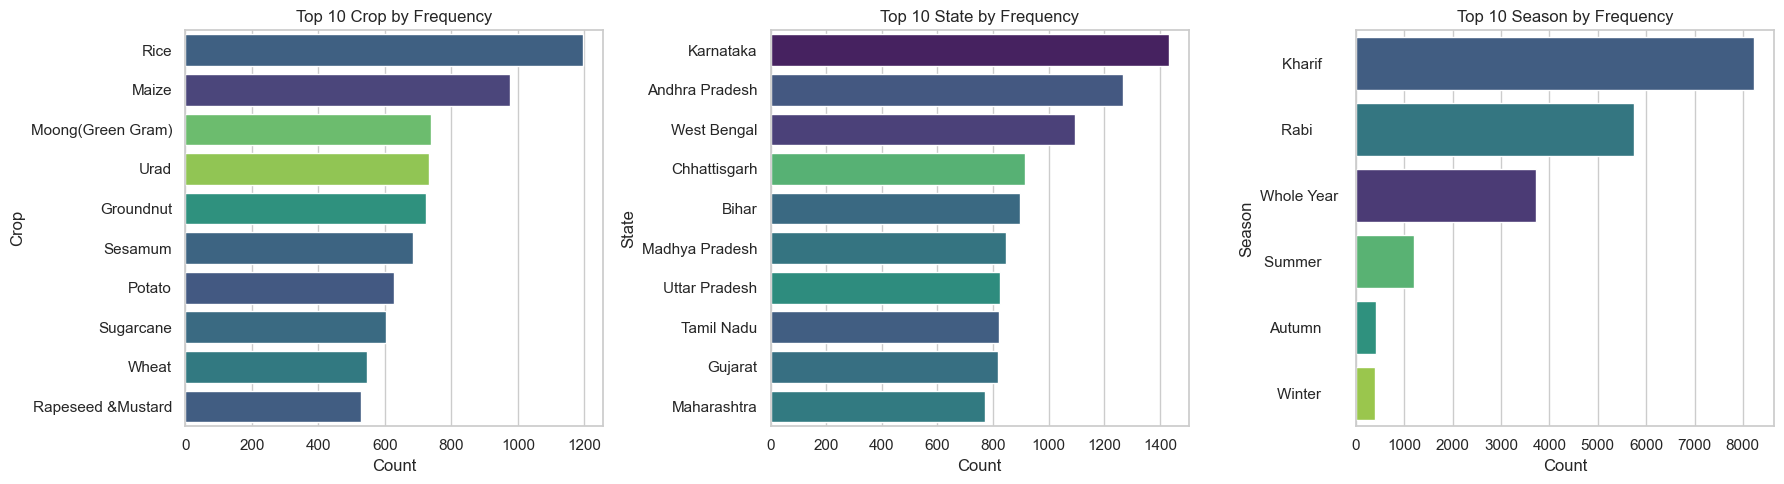

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['Crop', 'State', 'Season']):
    sns.countplot(
        y=col,
        data=df,
        order=df[col].value_counts().index[:10],
        ax=axes[i],
        hue=col,
        palette='viridis',
        legend=False
    )
    axes[i].set_title(f'Top 10 {col} by Frequency')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

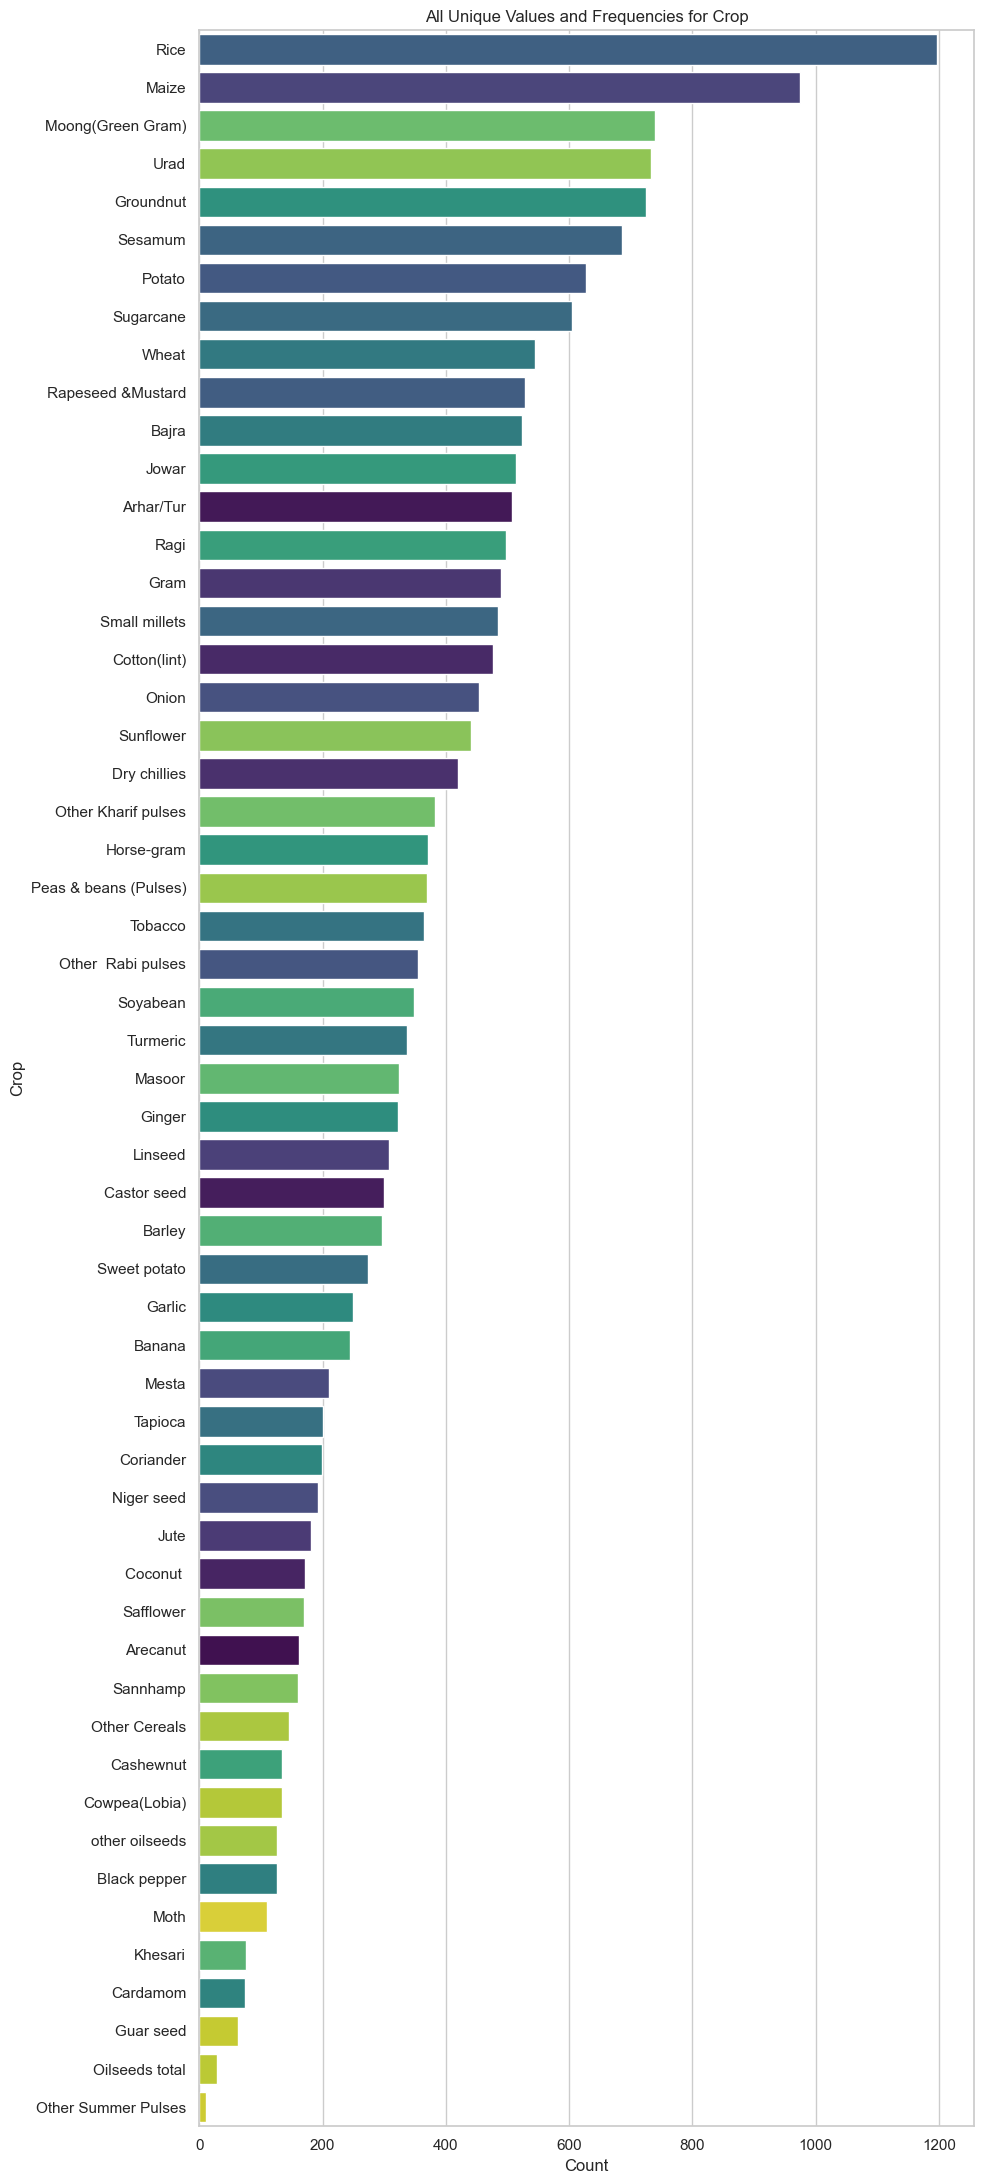

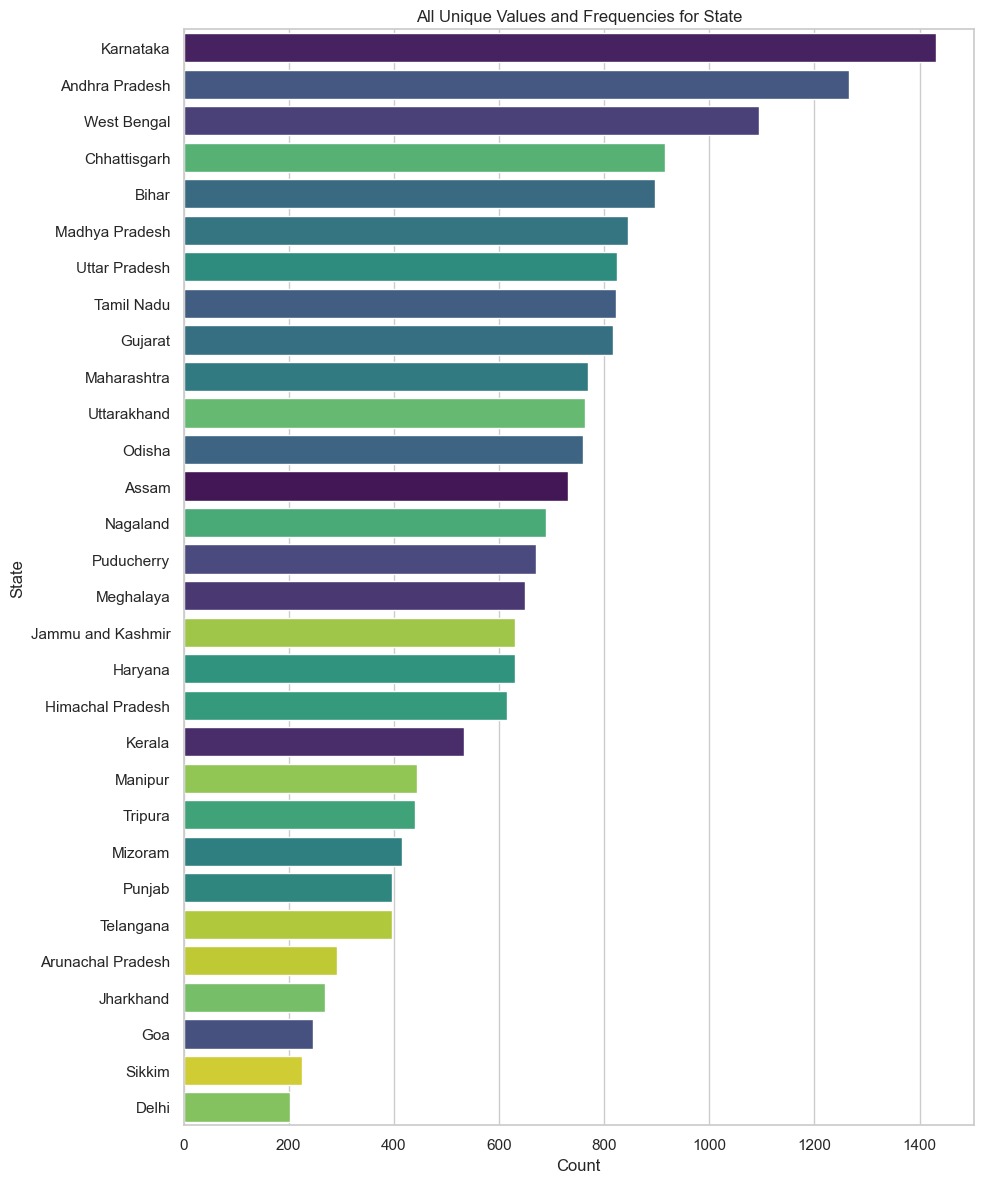

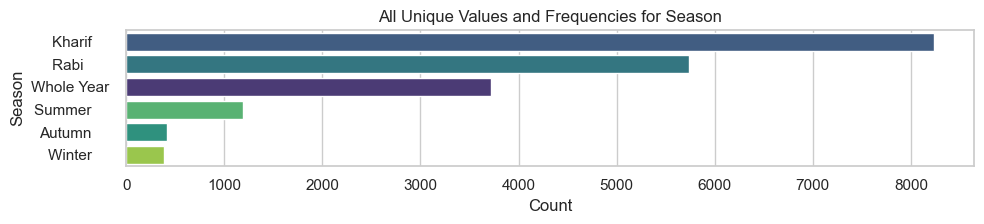

In [8]:
for col in categorical_cols:
    plt.figure(figsize=(10, 0.4 * len(df[col].value_counts())))
    sns.countplot(
        y=col,
        data=df,
        order=df[col].value_counts().index,
        hue=col,
        palette='viridis',
        legend=False
    )
    plt.title(f'All Unique Values and Frequencies for {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Como "Rice" o Arroz es el cultivo con mayor cantidad de datos, nos quedamos con ese.

In [ ]:
df_rice = df[df['Crop'].str.strip().str.lower() == 'rice'].copy()
print(f"Filtered dataset shape (Rice only): {df_rice.shape}")

Filtered dataset shape (Rice only): (1197, 10)


<class 'pandas.core.frame.DataFrame'>
Index: 1197 entries, 16 to 19687
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             1197 non-null   object 
 1   Crop_Year        1197 non-null   int64  
 2   Season           1197 non-null   object 
 3   State            1197 non-null   object 
 4   Area             1197 non-null   float64
 5   Production       1197 non-null   int64  
 6   Annual_Rainfall  1197 non-null   float64
 7   Fertilizer       1197 non-null   float64
 8   Pesticide        1197 non-null   float64
 9   Yield            1197 non-null   float64
dtypes: float64(5), int64(2), object(3)
memory usage: 102.9+ KB


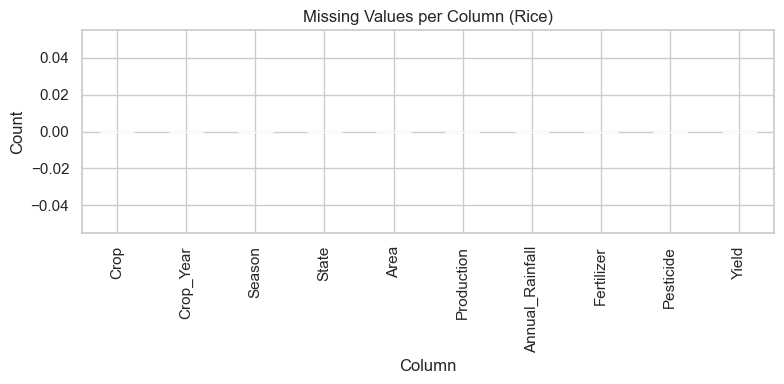

In [ ]:
df_rice.info()

df_rice.isnull().sum().plot(kind='bar', figsize=(8,4), color='tomato')
plt.title('Missing Values per Column (Rice)')
plt.ylabel('Count')
plt.xlabel('Column')
plt.tight_layout()
plt.show()

C:\Users\chuca\AppData\Local\Temp\ipykernel_9288\1276664897.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_rice, order=df_rice[col].value_counts().index, palette='viridis')


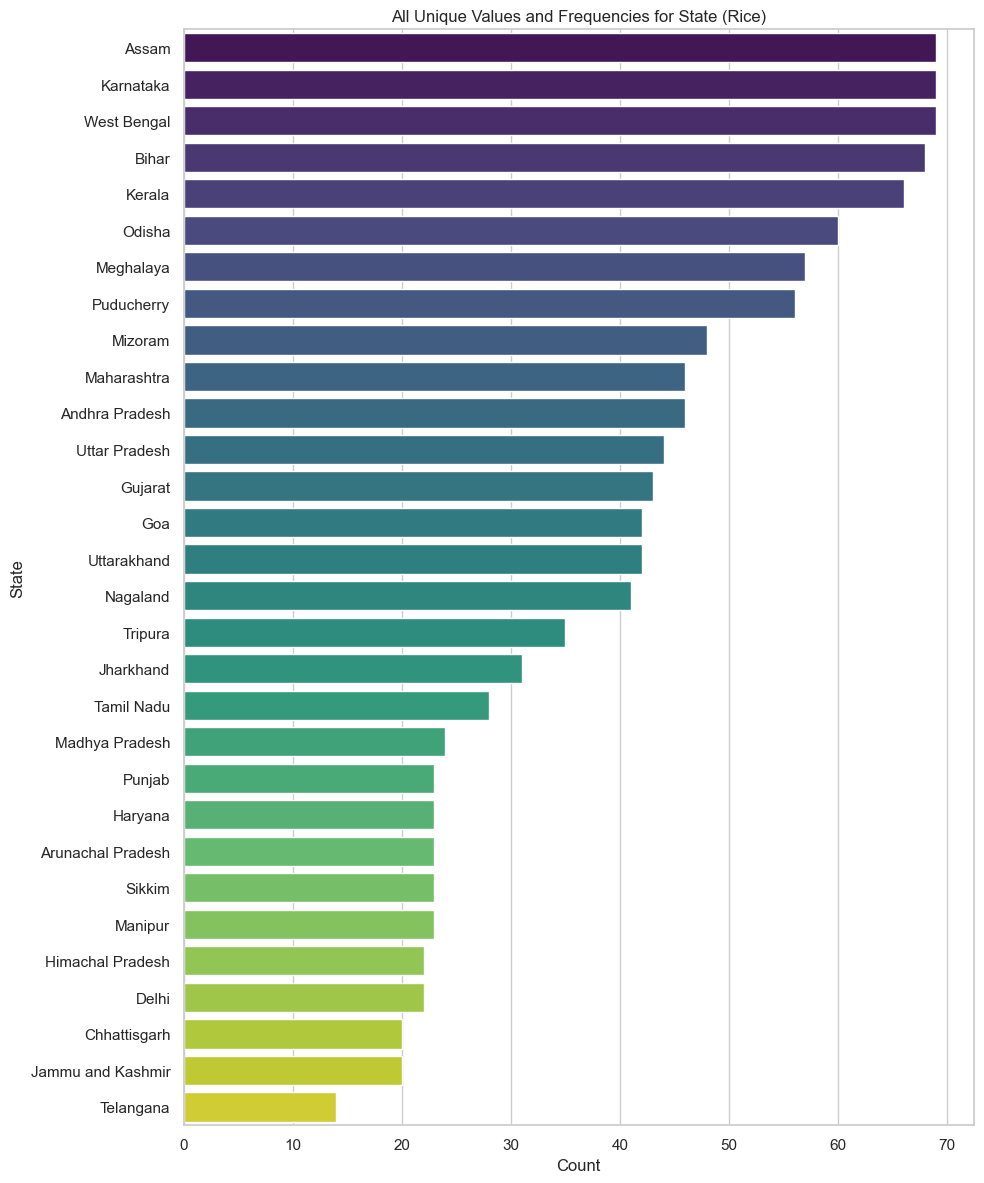

C:\Users\chuca\AppData\Local\Temp\ipykernel_9288\1276664897.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_rice, order=df_rice[col].value_counts().index, palette='viridis')


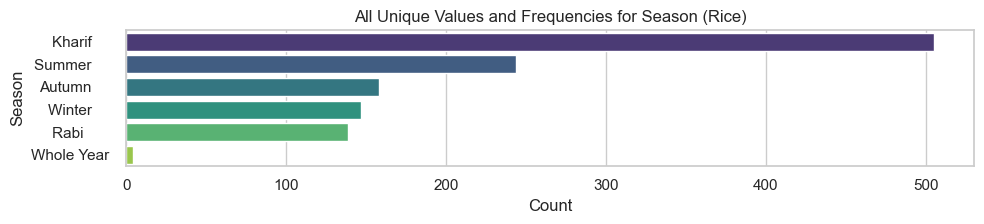

In [ ]:
categorical_cols = ['State', 'Season']
for col in categorical_cols:
    plt.figure(figsize=(10, 0.4 * len(df_rice[col].value_counts())))
    sns.countplot(y=col, data=df_rice, order=df_rice[col].value_counts().index, palette='viridis')
    plt.title(f'All Unique Values and Frequencies for {col} (Rice)')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

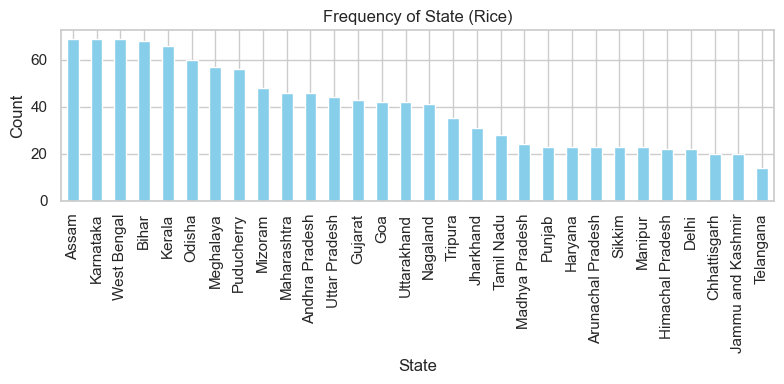

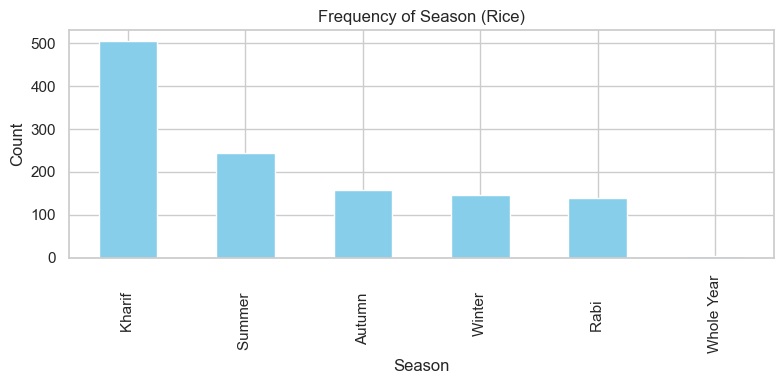

In [ ]:
for col in ['State', 'Season']:
    plt.figure(figsize=(8,4))
    df_rice[col].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'Frequency of {col} (Rice)')
    plt.ylabel('Count')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

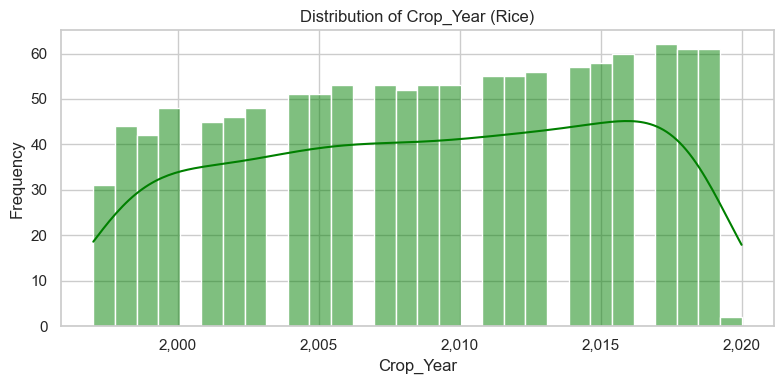

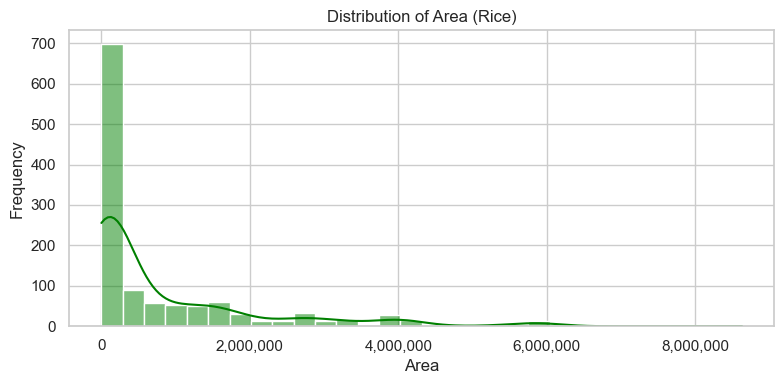

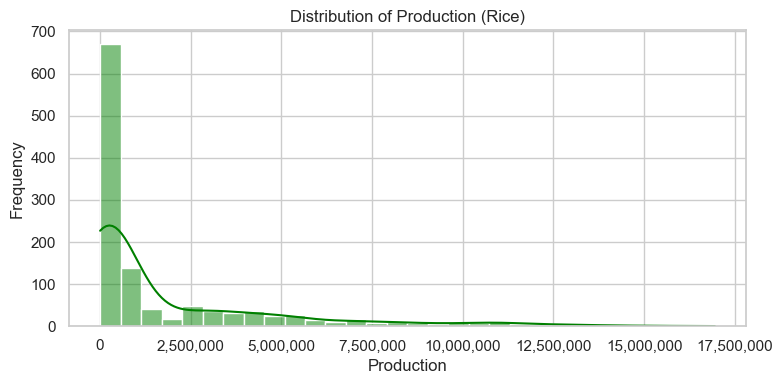

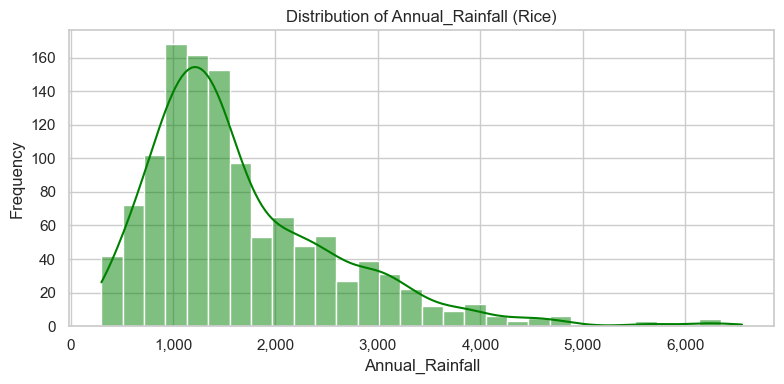

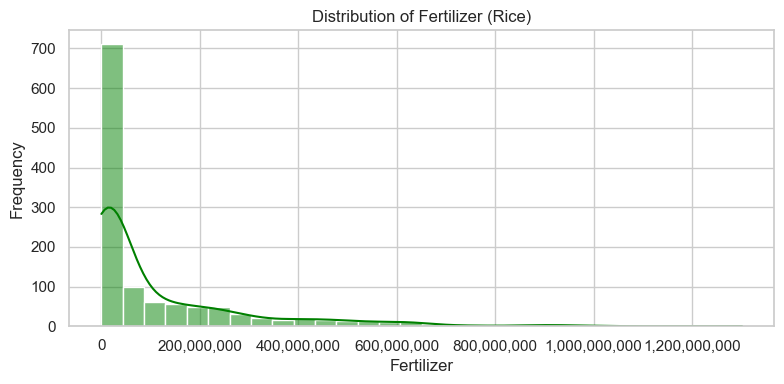

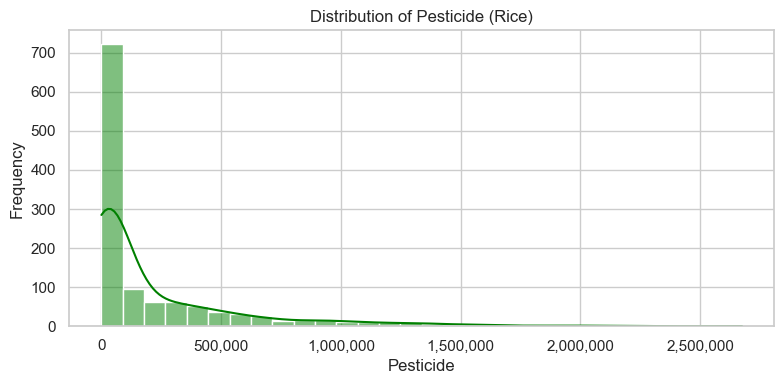

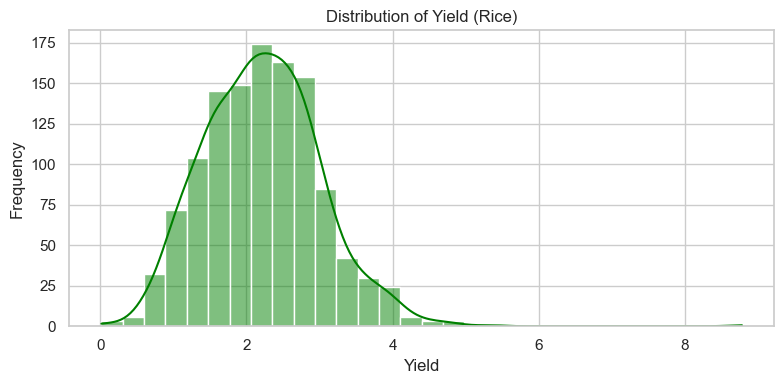

In [ ]:
import matplotlib.ticker as mticker
num_cols = df_rice.select_dtypes(include=[np.number]).columns
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df_rice[col].dropna(), kde=True, color='green', bins=30)
    plt.title(f'Distribution of {col} (Rice)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.show()

Como "Whole Year" o Todo el año no nos sirve realmente como dato ya que no podemos nisiquiera aproximar una fecha dada para luego rellenar el dataset con los datos faltantes, y además son pocos datos, podemos eliminarlos del dataset sin perder demasiada información.

In [ ]:
df_rice = df_rice[df_rice['Season'].str.strip().str.lower() != 'whole year'].copy()
print(f"Filas restantes tras eliminar 'Whole Year': {df_rice.shape[0]}")
print('Estaciones únicas restantes:', df_rice['Season'].unique())

Filas restantes tras eliminar 'Whole Year': 1193
Estaciones únicas restantes: ['Autumn     ' 'Summer     ' 'Winter     ' 'Kharif     ' 'Rabi       ']


Necesitamos también eliminar los espacios del texto en la columna de las estaciones.

In [ ]:
df_rice['Season'] = df_rice['Season'].str.strip()
print('Estaciones únicas después de limpiar espacios:', df_rice['Season'].unique())

Estaciones únicas después de limpiar espacios: ['Autumn' 'Summer' 'Winter' 'Kharif' 'Rabi']


In [16]:
df_rice

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
16,Rice,1997,Autumn,Assam,607358.0,398311,2051.4,5.780226e+07,188280.98,0.780870
17,Rice,1997,Summer,Assam,174974.0,209623,2051.4,1.665228e+07,54241.94,1.060435
18,Rice,1997,Winter,Assam,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.941304
51,Rice,1997,Kharif,Karnataka,1031530.0,2340493,1266.7,9.817071e+07,319774.30,2.233500
52,Rice,1997,Rabi,Karnataka,53889.0,109350,1266.7,5.128616e+06,16705.59,2.073846
...,...,...,...,...,...,...,...,...,...,...
19670,Rice,2018,Autumn,Odisha,454370.0,527490,1635.9,7.369881e+07,159029.50,1.322917
19671,Rice,2018,Summer,Odisha,274230.0,925810,1635.9,4.448011e+07,95980.50,2.586071
19672,Rice,2018,Winter,Odisha,3130820.0,6280410,1635.9,5.078190e+08,1095787.00,1.982333
19683,Rice,1998,Kharif,Nagaland,141000.0,205000,1498.0,1.393080e+07,40890.00,1.441429


Para agregar las coordenadas de los lugares usaremos información de la siguiente página:

https://simplemaps.com/data/in-cities


In [ ]:
# merge de coordenadas con normalización automática

# Instalar unidecode si no está presente (para manejar caracteres especiales)
try:
    import unidecode
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'unidecode'])
    import unidecode

try:
    locations
except NameError:
    locations = pd.read_csv('india_locations_latlon.csv')

# Normalizar columnas para merge (eliminar espacios, convertir a minúsculas, y quitar caracteres especiales)
df_rice['State_norm'] = df_rice['State'].str.strip().str.lower().apply(lambda x: unidecode.unidecode(x) if pd.notna(x) else x)
locations['admin_norm'] = locations['admin_name'].str.strip().str.lower().apply(lambda x: unidecode.unidecode(x) if pd.notna(x) else x)
locations['city_norm'] = locations['city'].str.strip().str.lower().apply(lambda x: unidecode.unidecode(x) if pd.notna(x) else x)

# Crear una columna unificada en locations: usar admin_name si no es NaN, sino city
locations['location_norm'] = locations['admin_norm'].fillna(locations['city_norm'])

# Merge: primero intentar con admin_name (estado), luego con city si no coincide
df_rice = df_rice.merge(
    locations[['location_norm', 'lat', 'lng']].drop_duplicates('location_norm'),
    left_on='State_norm',
    right_on='location_norm',
    how='left'
)

df_rice['Latitude'] = df_rice['lat']
df_rice['Longitude'] = df_rice['lng']

# Limpiar columnas temporales
df_rice.drop(['State_norm', 'location_norm', 'lat', 'lng'], axis=1, inplace=True)

print(f"Filas con Latitude después del merge: {df_rice['Latitude'].notna().sum()}")
print(f"Filas con Longitude después del merge: {df_rice['Longitude'].notna().sum()}")
print(f"Filas sin Latitude: {df_rice['Latitude'].isna().sum()}")
print(f"Filas sin Longitude: {df_rice['Longitude'].isna().sum()}")

print("\nEjemplos de filas con coordenadas asignadas:")
display(df_rice[['State', 'Latitude', 'Longitude']].dropna().head())

Filas con Latitude después del merge: 837
Filas con Longitude después del merge: 837
Filas sin Latitude: 356
Filas sin Longitude: 356

Ejemplos de filas con coordenadas asignadas:


,State,Latitude,Longitude
0,Assam,26.1722,91.7458
1,Assam,26.1722,91.7458
2,Assam,26.1722,91.7458
3,Karnataka,12.9789,77.5917
4,Karnataka,12.9789,77.5917


In [ ]:
print(f"Total rows in df_rice: {len(df_rice)}")
print(f"Rows with Latitude: {df_rice['Latitude'].notna().sum()}")
print(f"Rows with Longitude: {df_rice['Longitude'].notna().sum()}")
print(f"Rows missing Latitude: {df_rice['Latitude'].isna().sum()}")
print(f"Rows missing Longitude: {df_rice['Longitude'].isna().sum()}")


Total rows in df_rice: 1193
Rows with Latitude: 837
Rows with Longitude: 837
Rows missing Latitude: 356
Rows missing Longitude: 356


Son bastantes los datos que faltan con coordenadas, por lo tanto no podemos eliminarlos.

In [ ]:
try:
    locations
except NameError:
    locations = pd.read_csv('india_locations_latlon.csv')

unmatched_states = df_rice[df_rice['Latitude'].isna()]['State'].unique()
print(f"Total unique states in df_rice: {len(df_rice['State'].unique())}")
print(f"Unmatched states (sin coordenadas): {len(unmatched_states)}")
print("\nUnmatched states:")
for state in sorted(unmatched_states):
    print(f"  {state}")

print("\nChecking if unmatched states exist in locations CSV (city or admin_name):")
for state in sorted(unmatched_states):
    state_clean = state.strip().lower()
    exists_in_city = any(state_clean == city.lower() for city in locations['city'].dropna())
    exists_in_admin = any(state_clean == admin.lower() for admin in locations['admin_name'].dropna())
    print(f"  {state}: City match? {exists_in_city}, Admin match? {exists_in_admin}")

Total unique states in df_rice: 30
Unmatched states (sin coordenadas): 9

Unmatched states:
  Arunachal Pradesh
  Goa
  Kerala
  Manipur
  Meghalaya
  Mizoram
  Nagaland
  Sikkim
  Tripura

Checking if unmatched states exist in locations CSV (city or admin_name):
  Arunachal Pradesh: City match? False, Admin match? False
  Goa: City match? False, Admin match? False
  Kerala: City match? False, Admin match? False
  Manipur: City match? False, Admin match? False
  Meghalaya: City match? False, Admin match? False
  Mizoram: City match? False, Admin match? False
  Nagaland: City match? False, Admin match? False
  Sikkim: City match? False, Admin match? False
  Tripura: City match? False, Admin match? False


Como realmente son pocas las zonas que faltan dentro de la información dada por la página, podemos rellenar las zonas que faltan haciendo una búsqueda manual de coordenadas.

* Arunachal Pradesh: 28° 00' N, 95° 00' E
* Goa: 28° 38' N, 72° 12' E
* Kerala: 10° 00' N, 76° 25' E
* Manipur: 24° 44' N, 93° 58' E
* Meghalaya: 25° 30' N, 91° 00' E
* Mizoram: 23° 30' N, 20° 52' E
* Sikkim: 27.3 N, 88.3 E
* Tripura: 23° 45' N, 91° 30' E

Estas coordenadas fueron sacadas desde: https://www.mapsofindia.com/

In [ ]:
locations = pd.read_csv('india_locations_latlon.csv')

# Crear un diccionario de nombre a coordenadas
name_to_coords = {}
for _, row in locations.iterrows():
    name_to_coords[row['city']] = (row['lat'], row['lng'])
    name_to_coords[row['admin_name']] = (row['lat'], row['lng'])

from difflib import get_close_matches
state_to_coords = {}
for state in df_rice['State'].unique():
    state_clean = state.strip().lower()
    possible_names = list(name_to_coords.keys())
    possible_clean = [n.lower() for n in possible_names]
    matches = get_close_matches(state_clean, possible_clean, n=1, cutoff=0.8)
    if matches:
        matched_clean = matches[0]
        for orig in possible_names:
            if orig.lower() == matched_clean:
                state_to_coords[state] = name_to_coords[orig]
                break

# Agregar manualmente coordenadas para estados no encontrados
manual_coords = {
    'Arunachal Pradesh': (28.0, 95.0),
    'Goa': (28.6333, 72.2),
    'Kerala': (10.0, 76.4167),
    'Manipur': (24.7333, 93.9667),
    'Meghalaya': (25.5, 91.0),
    'Mizoram': (23.5, 20.8667),
    'Sikkim': (27.3, 88.3),
    'Tripura': (23.75, 91.5)
}
state_to_coords.update(manual_coords)

df_rice['Latitude'] = df_rice['State'].map(lambda x: state_to_coords.get(x, (None, None))[0])
df_rice['Longitude'] = df_rice['State'].map(lambda x: state_to_coords.get(x, (None, None))[1])

df_rice.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Latitude,Longitude
0,Rice,1997,Autumn,Assam,607358.0,398311,2051.4,5.780226e+07,188280.98,0.780870,26.1722,91.7458
1,Rice,1997,Summer,Assam,174974.0,209623,2051.4,1.665228e+07,54241.94,1.060435,26.1722,91.7458
2,Rice,1997,Winter,Assam,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.941304,26.1722,91.7458
3,Rice,1997,Kharif,Karnataka,1031530.0,2340493,1266.7,9.817071e+07,319774.30,2.233500,13.0633,77.4417
4,Rice,1997,Rabi,Karnataka,53889.0,109350,1266.7,5.128616e+06,16705.59,2.073846,13.0633,77.4417


In [ ]:
# Verificar estados sin coordenadas asignadas
all_states = set(df_rice['State'].unique())
matched_states = set(state_to_coords.keys())
unmatched_states = all_states - matched_states

print(f"Total unique states in df_rice: {len(all_states)}")
print(f"Matched states: {len(matched_states)}")
print(f"Unmatched states: {len(unmatched_states)}")
print("\nUnmatched states:")
for state in sorted(unmatched_states):
    print(f"  {state}")

print("\nChecking if unmatched states exist in locations CSV (city or admin_name):")
for state in sorted(unmatched_states):
    state_clean = state.strip().lower()
    exists_in_city = any(state_clean == city.lower() for city in locations['city'].dropna())
    exists_in_admin = any(state_clean == admin.lower() for admin in locations['admin_name'].dropna())
    print(f"  {state}: City match? {exists_in_city}, Admin match? {exists_in_admin}")

Total unique states in df_rice: 30
Matched states: 30
Unmatched states: 0

Unmatched states:

Checking if unmatched states exist in locations CSV (city or admin_name):


Con esto, ya conseguimos las coordenadas de todas las ubicaciones del dataset original.

In [22]:
df_rice.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Latitude,Longitude
0,Rice,1997,Autumn,Assam,607358.0,398311,2051.4,5.780226e+07,188280.98,0.780870,26.1722,91.7458
1,Rice,1997,Summer,Assam,174974.0,209623,2051.4,1.665228e+07,54241.94,1.060435,26.1722,91.7458
2,Rice,1997,Winter,Assam,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.941304,26.1722,91.7458
3,Rice,1997,Kharif,Karnataka,1031530.0,2340493,1266.7,9.817071e+07,319774.30,2.233500,13.0633,77.4417
4,Rice,1997,Rabi,Karnataka,53889.0,109350,1266.7,5.128616e+06,16705.59,2.073846,13.0633,77.4417


En este punto necesitaremos inferir algunas fechas aproximadas con los datos del año y la temporada, con el fin de poder tener mayor exactitud luego en los datos de clima y de suelo si es posible.

In [ ]:
# Para inferir fechas aproximadas de plantación y cosecha basadas en la temporada y el año
# La idea es definir reglas aproximadas para las temporadas comunes en India
# Kharif: Plantación en junio-julio, cosecha en septiembre-octubre
# Rabi: Plantación en octubre-noviembre, cosecha en marzo-abril
# Summer: Plantación en marzo, cosecha en junio
# Autumn: Plantación en septiembre, cosecha en diciembre
# Winter: Plantación en noviembre, cosecha en marzo (del año siguiente)

def infer_dates(season, year):
    season = season.strip().lower()
    if season == 'kharif':
        planting_month = 6  # Junio
        harvest_month = 10  # Octubre
    elif season == 'rabi':
        planting_month = 10  # Octubre
        harvest_month = 4   # Abril (del año siguiente)
    elif season == 'summer':
        planting_month = 3  # Marzo
        harvest_month = 6   # Junio
    elif season == 'autumn':
        planting_month = 9  # Septiembre
        harvest_month = 12  # Diciembre
    elif season == 'winter':
        planting_month = 11  # Noviembre
        harvest_month = 3   # Marzo (del año siguiente)
    else:
        return None, None  # Temporada desconocida

    planting_date = f"{year}-{planting_month:02d}-15"  # Aproximación a mediados de mes
    if harvest_month < planting_month:
        harvest_year = year + 1
    else:
        harvest_year = year
    harvest_date = f"{harvest_year}-{harvest_month:02d}-15"

    return planting_date, harvest_date

df_rice['Planting_Date'] = df_rice.apply(lambda row: infer_dates(row['Season'], row['Crop_Year'])[0], axis=1)
df_rice['Harvest_Date'] = df_rice.apply(lambda row: infer_dates(row['Season'], row['Crop_Year'])[1], axis=1)

print("Sample inferred dates:")
print(df_rice[['Season', 'Crop_Year', 'Planting_Date', 'Harvest_Date']].head())

Sample inferred dates:
   Season  Crop_Year Planting_Date Harvest_Date
0  Autumn       1997    1997-09-15   1997-12-15
1  Summer       1997    1997-03-15   1997-06-15
2  Winter       1997    1997-11-15   1998-03-15
3  Kharif       1997    1997-06-15   1997-10-15
4    Rabi       1997    1997-10-15   1998-04-15


In [24]:
df_rice.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Latitude,Longitude,Planting_Date,Harvest_Date
0,Rice,1997,Autumn,Assam,607358.0,398311,2051.4,5.780226e+07,188280.98,0.780870,26.1722,91.7458,1997-09-15,1997-12-15
1,Rice,1997,Summer,Assam,174974.0,209623,2051.4,1.665228e+07,54241.94,1.060435,26.1722,91.7458,1997-03-15,1997-06-15
2,Rice,1997,Winter,Assam,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.941304,26.1722,91.7458,1997-11-15,1998-03-15
3,Rice,1997,Kharif,Karnataka,1031530.0,2340493,1266.7,9.817071e+07,319774.30,2.233500,13.0633,77.4417,1997-06-15,1997-10-15
4,Rice,1997,Rabi,Karnataka,53889.0,109350,1266.7,5.128616e+06,16705.59,2.073846,13.0633,77.4417,1997-10-15,1998-04-15


Para los datos del clima utilizaremos la NASA POWER API.

https://power.larc.nasa.gov/docs/services/api/

In [ ]:
import requests
import json
import os
import time  # Para manejar esperas en 429

def get_nasa_power_data(lat, lng, start_year, end_year):
    """
    Buscar datos climáticos mensuales de la NASA POWER API para coordenadas y rango de fechas dados.
    Parámetros: PRECTOTCORR (precip), T2M (temp), ALLSKY_SFC_SW_DWN (radiación solar).
    """
    base_url = "https://power.larc.nasa.gov/api/temporal/monthly/point"
    params = {
        'start': start_year,  # Solo el año (YYYY)
        'end': end_year,      # Solo el año (YYYY)
        'latitude': lat,
        'longitude': lng,
        'community': 'RE',  # Renewable Energy (Requerido por la API)
        'parameters': 'PRECTOTCORR,T2M,ALLSKY_SFC_SW_DWN',
        'format': 'JSON'
    }
    while True:  # Loop para reintentos en 429
        response = requests.get(base_url, params=params)
        if response.status_code == 200:
            data = response.json()
            # Verificar si 'properties' y 'parameter' existen
            if 'properties' in data and 'parameter' in data['properties']:
                properties = data['properties']['parameter']
                # Extraer promedios o sumas con verificaciones
                precip = sum(properties.get('PRECTOTCORR', {}).values()) if 'PRECTOTCORR' in properties else None  # Total precip
                temp = sum(properties.get('T2M', {}).values()) / len(properties.get('T2M', {})) if 'T2M' in properties and properties['T2M'] else None  # Avg temp
                solar_rad = sum(properties.get('ALLSKY_SFC_SW_DWN', {}).values()) / len(properties.get('ALLSKY_SFC_SW_DWN', {})) if 'ALLSKY_SFC_SW_DWN' in properties and properties['ALLSKY_SFC_SW_DWN'] else None  # Avg solar radiation
                # Convertir radiación solar de W/m² a horas de sol (aprox.)
                sun_hours = solar_rad * 0.0036 if solar_rad is not None else None
                return precip, temp, sun_hours
            else:
                print(f"Unexpected response structure for lat={lat}, lng={lng}, start={start_year}, end={end_year}")
                return None, None, None
        elif response.status_code == 429:
            print(f"Too many requests (429) for lat={lat}, lng={lng}, start={start_year}, end={end_year}. Waiting 60 seconds...")
            time.sleep(60)
            continue  # Reintentar
        else:
            print(f"API error {response.status_code} for lat={lat}, lng={lng}, start={start_year}, end={end_year}: {response.text}")
            break  # Detener para otros errores
    return None, None, None

# Guardar df_rice antes de las llamadas a la API
df_rice.to_csv('df_rice_before_api.csv', index=False)
print("Saved df_rice to df_rice_before_api.csv")

# Cargar cache si existe
cache_file = 'climate_cache.json'
if os.path.exists(cache_file):
    with open(cache_file, 'r') as f:
        climate_cache = json.load(f)
else:
    climate_cache = {}

# Agrupar por State, Season, Crop_Year para minimizar llamadas repetidas
grouped = df_rice.groupby(['State', 'Season', 'Crop_Year'])

df_rice['Precip_Accumulated'] = None
df_rice['Temp_Mean'] = None
df_rice['Sun_Hours'] = None

for (state, season, year), group in grouped:
    lat = group['Latitude'].iloc[0]
    lng = group['Longitude'].iloc[0]
    planting_date = group['Planting_Date'].iloc[0]
    harvest_date = group['Harvest_Date'].iloc[0]
    
    if pd.isna(lat) or pd.isna(lng):
        print(f"Skipping group {state}, {season}, {year}: Missing coordinates")
        continue
    
    start_year = planting_date[:4] if planting_date else str(year)
    end_year = harvest_date[:4] if harvest_date else str(year)
    
    # Crear una clave única para el cache
    cache_key = f"{lat}_{lng}_{start_year}_{end_year}"
    
    if cache_key in climate_cache:
        precip, temp, sun_h = climate_cache[cache_key]
    else:
        precip, temp, sun_h = get_nasa_power_data(lat, lng, start_year, end_year)
        climate_cache[cache_key] = (precip, temp, sun_h)
        
        # Guardar cache después de cada nueva entrada
        with open(cache_file, 'w') as f:
            json.dump(climate_cache, f)
    
    df_rice.loc[group.index, 'Precip_Accumulated'] = precip
    df_rice.loc[group.index, 'Temp_Mean'] = temp
    df_rice.loc[group.index, 'Sun_Hours'] = sun_h

# Guardar df_rice después de las llamadas a la API
df_rice.to_csv('df_rice_after_api.csv', index=False)
print("Saved df_rice to df_rice_after_api.csv")
print(f"Total API calls made: {len(climate_cache)} (cached for reuse)")

Saved df_rice to df_rice_before_api.csv
Saved df_rice to df_rice_after_api.csv
Total API calls made: 922 (cached for reuse)


In [27]:
# Verificar valores None en las nuevas columnas climáticas
new_cols = ['Precip_Accumulated', 'Temp_Mean', 'Sun_Hours']
for col in new_cols:
    none_count = df_rice[col].isna().sum()
    print(f"Column '{col}': {none_count} None values out of {len(df_rice)} rows")

# Mostrar ejemplos de filas con None (hasta 5 por columna)
for col in new_cols:
    none_rows = df_rice[df_rice[col].isna()].head(5)
    if not none_rows.empty:
        print(f"\nEjemplos de filas con None en '{col}':")
        display(none_rows[['State', 'Season', 'Crop_Year', 'Latitude', 'Longitude', col]])
    else:
        print(f"\nNo None values in '{col}'")

Column 'Precip_Accumulated': 0 None values out of 1193 rows
Column 'Temp_Mean': 0 None values out of 1193 rows
Column 'Sun_Hours': 0 None values out of 1193 rows

No None values in 'Precip_Accumulated'

No None values in 'Temp_Mean'

No None values in 'Sun_Hours'


Esta última celda nos verifica que todos los datos fueron correctamente añadidos desde la API del clima.

La ejecución de las llamadas a la API tardó 150 minutos, por lo tanto de ahora en adelante se utilizará únicamente el dataframe que fue almacenado luego de la ejecución de las llamadas a la API llamado df_rice_after_api.csv.

In [4]:
df_rice = pd.read_csv('df_rice_after_api.csv')
df_rice.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Latitude,Longitude,Planting_Date,Harvest_Date,Precip_Accumulated,Temp_Mean,Sun_Hours
0,Rice,1997,Autumn,Assam,607358.0,398311,2051.4,5.780226e+07,188280.98,0.780870,26.1722,91.7458,1997-09-15,1997-12-15,52.08,22.377692,0.016033
1,Rice,1997,Summer,Assam,174974.0,209623,2051.4,1.665228e+07,54241.94,1.060435,26.1722,91.7458,1997-03-15,1997-06-15,52.08,22.377692,0.016033
2,Rice,1997,Winter,Assam,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.941304,26.1722,91.7458,1997-11-15,1998-03-15,112.31,22.670000,0.016187
3,Rice,1997,Kharif,Karnataka,1031530.0,2340493,1266.7,9.817071e+07,319774.30,2.233500,13.0633,77.4417,1997-06-15,1997-10-15,31.83,23.542308,0.019598
4,Rice,1997,Rabi,Karnataka,53889.0,109350,1266.7,5.128616e+06,16705.59,2.073846,13.0633,77.4417,1997-10-15,1998-04-15,73.69,23.640000,0.019662


Utilizamos la API GraphQL de WoSIS para la información del suelo

In [ ]:

import requests
import json
import os
import time
from math import radians, sin, cos, sqrt, atan2

# WoSIS GraphQL endpoint
WOSIS_GRAPHQL_URL = "https://graphql.isric.org/wosis/graphql"

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

def fetch_profiles_for_bbox(min_lat, max_lat, min_lon, max_lon, year_start, year_end, first_profiles=10, first_layers=20, first_values=10):
    query = """
    query SoilPropertiesForLocation(
      $minLat: Float!,
      $maxLat: Float!,
      $minLon: Float!,
      $maxLon: Float!,
      $yearStart: Int,
      $yearEnd: Int,
      $firstProfiles: Int!,
      $firstLayers: Int!,
      $firstValues: Int!
    ) {
      wosisLatestProfiles(
        filter: {
          latitude: { greaterThanOrEqualTo: $minLat, lessThanOrEqualTo: $maxLat },
          longitude: { greaterThanOrEqualTo: $minLon, lessThanOrEqualTo: $maxLon },
          year: { greaterThanOrEqualTo: $yearStart, lessThanOrEqualTo: $yearEnd }
        },
        first: $firstProfiles
      ) {
        profileId
        profileCode
        year
        site {
          latitude
          longitude
          countryName
        }
        layers(first: $firstLayers) {
          layerId
          layerName
          upperDepth
          lowerDepth
          phaqValues(first: $firstValues) { value upperDepth lowerDepth }
          nitkjdValues(first: $firstValues) { value upperDepth lowerDepth }
          orgmValues(first: $firstValues) { value upperDepth lowerDepth }
          phetolValues(first: $firstValues) { value upperDepth lowerDepth }
          wg0006Values(first: $firstValues) { value upperDepth lowerDepth }
        }
      }
    }
    """
    variables = {
        "minLat": min_lat,
        "maxLat": max_lat,
        "minLon": min_lon,
        "maxLon": max_lon,
        "yearStart": year_start,
        "yearEnd": year_end,
        "firstProfiles": first_profiles,
        "firstLayers": first_layers,
        "firstValues": first_values
    }
    while True:
        response = requests.post(WOSIS_GRAPHQL_URL, json={"query": query, "variables": variables})
        if response.status_code == 200:
            data = response.json()
            if "data" in data and "wosisLatestProfiles" in data["data"]:
                return data["data"]["wosisLatestProfiles"]
            else:
                print(f"Unexpected GraphQL response structure for bbox {min_lat},{max_lat},{min_lon},{max_lon}")
                return []
        elif response.status_code == 429:
            print(f"Too many requests (429) for bbox {min_lat},{max_lat},{min_lon},{max_lon}. Waiting 60 seconds...")
            time.sleep(60)
            continue
        else:
            print(f"GraphQL error {response.status_code} for bbox {min_lat},{max_lat},{min_lon},{max_lon}: {response.text}")
            return []

def get_soil_data_for_point(lat, lon, year, max_delta=50.0):
    year_start = int(max(1900, year - 10))
    year_end = int(min(2025, year + 10))
    
    # Verificar cache primero (ahora por bbox)
    cache_hit = False
    for cache_key, profiles in soil_cache.items():
        min_lat_c, max_lat_c, min_lon_c, max_lon_c, year_start_c, year_end_c = map(float, cache_key.split('_'))
        if (min_lat_c <= lat <= max_lat_c and 
            min_lon_c <= lon <= max_lon_c and 
            year_start_c <= year <= year_end_c):
            # Usar perfiles en caché
            cache_hit = True
            if profiles:
                # Encontrar el mejor perfil por distancia
                best = None
                best_dist = float('inf')
                for prof in profiles:
                    site = prof.get("site", {})
                    plat = site.get("latitude")
                    plon = site.get("longitude")
                    if plat is None or plon is None:
                        continue
                    dist = haversine(lat, lon, plat, plon)
                    if dist < best_dist:
                        best = prof
                        best_dist = dist
                if best:
                    print(f"  Cache hit: found profile for lat={lat}, lon={lon}, year={year}")
                    return extract_soil_data(best)
            print(f"  Cache hit but no suitable profile for lat={lat}, lon={lon}, year={year}")
            return None  # Si no hay perfiles en caché, continuar para buscar con max_delta

    if not cache_hit:
        print(f"  No cache hit, fetching new data for lat={lat}, lon={lon}, year={year}")
    
    # Definir bbox alrededor del punto
    min_lat = lat - max_delta
    max_lat = lat + max_delta
    min_lon = lon - max_delta
    max_lon = lon + max_delta

    cache_key = f"{min_lat}_{max_lat}_{min_lon}_{max_lon}_{year_start}_{year_end}"
    if cache_key in soil_cache:
        profiles = soil_cache[cache_key]
    else:
        print(f"  Making API call for bbox {min_lat},{max_lat},{min_lon},{max_lon}")
        profiles = fetch_profiles_for_bbox(min_lat, max_lat, min_lon, max_lon, year_start, year_end)
        soil_cache[cache_key] = profiles
        with open(soil_cache_file, 'w') as f:
            json.dump(soil_cache, f)

    if profiles:
        # Encontrar el perfil más cercano por distancia
        best = None
        best_dist = float('inf')
        for prof in profiles:
            site = prof.get("site", {})
            plat = site.get("latitude")
            plon = site.get("longitude")
            if plat is None or plon is None:
                continue
            dist = haversine(lat, lon, plat, plon)
            if dist < best_dist:
                best = prof
                best_dist = dist
        if best:
            return extract_soil_data(best)

    print(f"  No profiles found with max_delta={max_delta} for lat={lat}, lon={lon}, year={year}")
    return None  # Si aun no se encuentran perfiles, devolver None.


def extract_soil_data(profile):
    layers = profile.get("layers", [])
    ph_values = []
    nitrogen_values = []
    organic_carbon_values = []
    phosphorus_values = []
    humidity_values = []

    for layer in layers:
        # pH
        for val in layer.get("phaqValues", []):
            if val.get("value"):
                ph_values.append(float(val["value"][0]))
        # Nitrogen
        for val in layer.get("nitkjdValues", []):
            if val.get("value"):
                nitrogen_values.append(float(val["value"][0]))
        # Organic carbon (orgmValues)
        for val in layer.get("orgmValues", []):
            if val.get("value"):
                organic_carbon_values.append(float(val["value"][0]))
        # Phosphorus (phetolValues)
        for val in layer.get("phetolValues", []):
            if val.get("value"):
                phosphorus_values.append(float(val["value"][0]))
        # Humidity (wg0006Values)
        for val in layer.get("wg0006Values", []):
            if val.get("value"):
                humidity_values.append(float(val["value"][0]))

    # Calcular promedios si hay varios valores en distintas capas.
    ph = sum(ph_values) / len(ph_values) if ph_values else None
    nitrogen = sum(nitrogen_values) / len(nitrogen_values) if nitrogen_values else None
    organic_carbon = sum(organic_carbon_values) / len(organic_carbon_values) if organic_carbon_values else None
    phosphorus = sum(phosphorus_values) / len(phosphorus_values) if phosphorus_values else None
    humidity = sum(humidity_values) / len(humidity_values) if humidity_values else None

    return {
        "Soil_pH": ph,
        "Soil_Humidity": humidity,
        "Soil_Nitrogen": nitrogen,
        "Soil_Phosphorus": phosphorus,
        "Soil_Potassium": None,  # No disponible en WoSIS
        "Soil_Organic_Carbon": organic_carbon
    }

# Cargar cache de suelo si existe
soil_cache_file = 'soil_cache.json'
if os.path.exists(soil_cache_file):
    with open(soil_cache_file, 'r') as f:
        soil_cache = json.load(f)
else:
    soil_cache = {}

# Agrupar por coordenadas y año para minimizar llamadas repetidas
grouped_coords = df_rice.groupby(['Latitude', 'Longitude', 'Crop_Year'])

df_rice['Soil_pH'] = None
df_rice['Soil_Humidity'] = None
df_rice['Soil_Nitrogen'] = None
df_rice['Soil_Phosphorus'] = None
df_rice['Soil_Potassium'] = None
df_rice['Soil_Organic_Carbon'] = None

total_groups = len(grouped_coords)
print(f"Starting processing of {total_groups} unique groups...")

for i, ((lat, lng, year), group) in enumerate(grouped_coords):
    print(f"Processing group {i+1}/{total_groups} (lat={lat}, lng={lng}, year={year}) - {len(group)} rows")
    
    if pd.isna(lat) or pd.isna(lng):
        print(f"  Skipping: Missing coordinates")
        continue
    
    soil_data = get_soil_data_for_point(lat, lng, year)
    
    if soil_data:
        for col, val in soil_data.items():
            df_rice.loc[group.index, col] = val
        print(f"  Assigned soil data")
    else:
        print(f"  No soil data found")

print(f"Finished processing all groups.")

df_rice.to_csv('df_rice_with_soil.csv', index=False)
print("Saved df_rice with soil data to df_rice_with_soil.csv")
print(f"Total unique groups processed: {total_groups}")
print(f"Total API calls made: {len([k for k in soil_cache.keys() if soil_cache[k]])} (cached for reuse)")



Starting processing of 647 unique groups...
Processing group 1/647 (lat=10.0, lng=76.4167, year=1998) - 3 rows
  Cache hit but no suitable profile for lat=10.0, lon=76.4167, year=1998
  No soil data found
Processing group 2/647 (lat=10.0, lng=76.4167, year=1999) - 3 rows
  Cache hit but no suitable profile for lat=10.0, lon=76.4167, year=1999
  No soil data found
Processing group 3/647 (lat=10.0, lng=76.4167, year=2000) - 3 rows
  Cache hit but no suitable profile for lat=10.0, lon=76.4167, year=2000
  No soil data found
Processing group 4/647 (lat=10.0, lng=76.4167, year=2001) - 3 rows
  Cache hit but no suitable profile for lat=10.0, lon=76.4167, year=2001
  No soil data found
Processing group 5/647 (lat=10.0, lng=76.4167, year=2002) - 3 rows
  Cache hit but no suitable profile for lat=10.0, lon=76.4167, year=2002
  No soil data found
Processing group 6/647 (lat=10.0, lng=76.4167, year=2003) - 3 rows
  Cache hit but no suitable profile for lat=10.0, lon=76.4167, year=2003
  No soil d

In [14]:
# Verificar valores None en las nuevas columnas de suelo (excluyendo Soil_Potassium que siempre es None)
new_soil_cols = ['Soil_pH', 'Soil_Humidity', 'Soil_Nitrogen', 'Soil_Phosphorus', 'Soil_Organic_Carbon']
for col in new_soil_cols:
    none_count = df_rice[col].isna().sum()
    print(f"Column '{col}': {none_count} None values out of {len(df_rice)} rows")

# Mostrar ejemplos de filas con None (hasta 5 por columna)
for col in new_soil_cols:
    none_rows = df_rice[df_rice[col].isna()].head(5)
    if not none_rows.empty:
        print(f"\nEjemplos de filas con None en '{col}':")
        display(none_rows[['State', 'Season', 'Crop_Year', 'Latitude', 'Longitude', col]])
    else:
        print(f"\nNo None values in '{col}'")

Column 'Soil_pH': 610 None values out of 1193 rows
Column 'Soil_Humidity': 1193 None values out of 1193 rows
Column 'Soil_Nitrogen': 324 None values out of 1193 rows
Column 'Soil_Phosphorus': 1193 None values out of 1193 rows
Column 'Soil_Organic_Carbon': 1193 None values out of 1193 rows

Ejemplos de filas con None en 'Soil_pH':


,State,Season,Crop_Year,Latitude,Longitude,Soil_pH
3,Karnataka,Kharif,1997,13.0633,77.4417,None
4,Karnataka,Rabi,1997,13.0633,77.4417,None
5,Karnataka,Summer,1997,13.0633,77.4417,None
10,Puducherry,Kharif,1998,11.9167,79.8167,None
11,Puducherry,Rabi,1998,11.9167,79.8167,None



Ejemplos de filas con None en 'Soil_Humidity':


,State,Season,Crop_Year,Latitude,Longitude,Soil_Humidity
0,Assam,Autumn,1997,26.1722,91.7458,None
1,Assam,Summer,1997,26.1722,91.7458,None
2,Assam,Winter,1997,26.1722,91.7458,None
3,Karnataka,Kharif,1997,13.0633,77.4417,None
4,Karnataka,Rabi,1997,13.0633,77.4417,None



Ejemplos de filas con None en 'Soil_Nitrogen':


,State,Season,Crop_Year,Latitude,Longitude,Soil_Nitrogen
3,Karnataka,Kharif,1997,13.0633,77.4417,None
4,Karnataka,Rabi,1997,13.0633,77.4417,None
5,Karnataka,Summer,1997,13.0633,77.4417,None
18,Karnataka,Kharif,1998,13.0633,77.4417,None
19,Karnataka,Rabi,1998,13.0633,77.4417,None



Ejemplos de filas con None en 'Soil_Phosphorus':


,State,Season,Crop_Year,Latitude,Longitude,Soil_Phosphorus
0,Assam,Autumn,1997,26.1722,91.7458,None
1,Assam,Summer,1997,26.1722,91.7458,None
2,Assam,Winter,1997,26.1722,91.7458,None
3,Karnataka,Kharif,1997,13.0633,77.4417,None
4,Karnataka,Rabi,1997,13.0633,77.4417,None



Ejemplos de filas con None en 'Soil_Organic_Carbon':


,State,Season,Crop_Year,Latitude,Longitude,Soil_Organic_Carbon
0,Assam,Autumn,1997,26.1722,91.7458,None
1,Assam,Summer,1997,26.1722,91.7458,None
2,Assam,Winter,1997,26.1722,91.7458,None
3,Karnataka,Kharif,1997,13.0633,77.4417,None
4,Karnataka,Rabi,1997,13.0633,77.4417,None


Luego de las primeras llamadas a la API con las consideraciones que tuvimos, existen muchos valores None los cuales podemos intentar aproximar de alguna manera, pero también, existen 4 columnas las cuales están completamente vacías, y para ellas necesitamos aplicar otro tipo de técnicas.

In [ ]:
import pandas as pd
import numpy as np

# Cargar el dataframe con datos de suelo
df_rice = pd.read_csv('df_rice_with_soil.csv')

# Columnas de suelo a verificar
soil_cols = ['Soil_pH', 'Soil_Humidity', 'Soil_Nitrogen', 'Soil_Phosphorus', 'Soil_Organic_Carbon']

# Función para calcular distancia
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radio de la Tierra en km
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# Recopilar todos los perfiles de cache
all_profiles = []
for cache_key, profiles in soil_cache.items():
    if profiles:
        all_profiles.extend(profiles)

print(f"Total profiles in cache: {len(all_profiles)}")

total_rows = len(df_rice)
# Asignar el más cercano global para todas las filas con None
for idx, row in df_rice.iterrows():
    lat, lng = row['Latitude'], row['Longitude']
    if pd.isna(lat) or pd.isna(lng):
        continue
    
    has_none = any(pd.isna(row[col]) for col in soil_cols)
    if not has_none:
        continue
    
    print(f"Filling None for row {idx} with global closest of {total_rows}", end='\r', flush=True)
    
    # Encontrar perfil más cercano
    best = None
    best_dist = float('inf')
    for prof in all_profiles:
        site = prof.get("site", {})
        plat = site.get("latitude")
        plon = site.get("longitude")
        if plat is None or plon is None:
            continue
        dist = haversine(lat, lng, plat, plon)
        if dist < best_dist:
            best = prof
            best_dist = dist
    
    if best:
        soil_data = extract_soil_data(best)
        for col in soil_cols:
            if pd.isna(row[col]) and soil_data.get(col) is not None:
                df_rice.at[idx, col] = soil_data[col]

# Para las columnas que aún tengan None, asignar valores manuales (media de la columna)
for col in soil_cols:
    if df_rice[col].isna().any():
        mean_val = df_rice[col].mean()
        df_rice[col].fillna(mean_val, inplace=True)
        print(f"Filled remaining None in '{col}' with mean value: {mean_val}")

# Verificar None finales
for col in soil_cols:
    none_count = df_rice[col].isna().sum()
    print(f"Final None in '{col}': {none_count}")

# Guardar
df_rice.to_csv('df_rice_filled_soil.csv', index=False)
print("Saved filled dataframe to df_rice_filled_soil.csv")

Total profiles in cache: 3967


Filled remaining None in 'Soil_pH' with mean value: 6.609240608075417
Filled remaining None in 'Soil_Humidity' with mean value: nan
Filled remaining None in 'Soil_Nitrogen' with mean value: 0.9446072796934866
Filled remaining None in 'Soil_Phosphorus' with mean value: nan
Filled remaining None in 'Soil_Organic_Carbon' with mean value: nan
Final None in 'Soil_pH': 0
Final None in 'Soil_Humidity': 1193
Final None in 'Soil_Nitrogen': 0
Final None in 'Soil_Phosphorus': 1193
Final None in 'Soil_Organic_Carbon': 1193
Saved filled dataframe to df_rice_filled_soil.csv


C:\Users\chuca\AppData\Local\Temp\ipykernel_4456\3919686429.py:66: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_rice[col].fillna(mean_val, inplace=True)


In [23]:
# Verificar valores None en las nuevas columnas de suelo (excluyendo Soil_Potassium que siempre es None)
new_soil_cols = ['Soil_pH', 'Soil_Humidity', 'Soil_Nitrogen', 'Soil_Phosphorus', 'Soil_Organic_Carbon']
for col in new_soil_cols:
    none_count = df_rice[col].isna().sum()
    print(f"Column '{col}': {none_count} None values out of {len(df_rice)} rows")

# Mostrar ejemplos de filas con None (hasta 5 por columna)
for col in new_soil_cols:
    none_rows = df_rice[df_rice[col].isna()].head(5)
    if not none_rows.empty:
        print(f"\nEjemplos de filas con None en '{col}':")
        display(none_rows[['State', 'Season', 'Crop_Year', 'Latitude', 'Longitude', col]])
    else:
        print(f"\nNo None values in '{col}'")

Column 'Soil_pH': 0 None values out of 1193 rows
Column 'Soil_Humidity': 1193 None values out of 1193 rows
Column 'Soil_Nitrogen': 0 None values out of 1193 rows
Column 'Soil_Phosphorus': 1193 None values out of 1193 rows
Column 'Soil_Organic_Carbon': 1193 None values out of 1193 rows

No None values in 'Soil_pH'

Ejemplos de filas con None en 'Soil_Humidity':


,State,Season,Crop_Year,Latitude,Longitude,Soil_Humidity
0,Assam,Autumn,1997,26.1722,91.7458,NaN
1,Assam,Summer,1997,26.1722,91.7458,NaN
2,Assam,Winter,1997,26.1722,91.7458,NaN
3,Karnataka,Kharif,1997,13.0633,77.4417,NaN
4,Karnataka,Rabi,1997,13.0633,77.4417,NaN



No None values in 'Soil_Nitrogen'

Ejemplos de filas con None en 'Soil_Phosphorus':


,State,Season,Crop_Year,Latitude,Longitude,Soil_Phosphorus
0,Assam,Autumn,1997,26.1722,91.7458,NaN
1,Assam,Summer,1997,26.1722,91.7458,NaN
2,Assam,Winter,1997,26.1722,91.7458,NaN
3,Karnataka,Kharif,1997,13.0633,77.4417,NaN
4,Karnataka,Rabi,1997,13.0633,77.4417,NaN



Ejemplos de filas con None en 'Soil_Organic_Carbon':


,State,Season,Crop_Year,Latitude,Longitude,Soil_Organic_Carbon
0,Assam,Autumn,1997,26.1722,91.7458,NaN
1,Assam,Summer,1997,26.1722,91.7458,NaN
2,Assam,Winter,1997,26.1722,91.7458,NaN
3,Karnataka,Kharif,1997,13.0633,77.4417,NaN
4,Karnataka,Rabi,1997,13.0633,77.4417,NaN


In [24]:
df_rice

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,...,Harvest_Date,Precip_Accumulated,Temp_Mean,Sun_Hours,Soil_pH,Soil_Humidity,Soil_Nitrogen,Soil_Phosphorus,Soil_Potassium,Soil_Organic_Carbon
0,Rice,1997,Autumn,Assam,607358.0,398311,2051.4,5.780226e+07,188280.98,0.780870,...,1997-12-15,52.08,22.377692,0.016033,4.950000,NaN,2.266667,NaN,NaN,NaN
1,Rice,1997,Summer,Assam,174974.0,209623,2051.4,1.665228e+07,54241.94,1.060435,...,1997-06-15,52.08,22.377692,0.016033,4.950000,NaN,2.266667,NaN,NaN,NaN
2,Rice,1997,Winter,Assam,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.941304,...,1998-03-15,112.31,22.670000,0.016187,4.950000,NaN,2.266667,NaN,NaN,NaN
3,Rice,1997,Kharif,Karnataka,1031530.0,2340493,1266.7,9.817071e+07,319774.30,2.233500,...,1997-10-15,31.83,23.542308,0.019598,6.555556,NaN,0.944607,NaN,NaN,NaN
4,Rice,1997,Rabi,Karnataka,53889.0,109350,1266.7,5.128616e+06,16705.59,2.073846,...,1998-04-15,73.69,23.640000,0.019662,6.555556,NaN,0.944607,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1188,Rice,2018,Autumn,Odisha,454370.0,527490,1635.9,7.369881e+07,159029.50,1.322917,...,2018-12-15,67.49,26.013846,0.017077,6.609241,NaN,1.140000,NaN,NaN,NaN
1189,Rice,2018,Summer,Odisha,274230.0,925810,1635.9,4.448011e+07,95980.50,2.586071,...,2018-06-15,67.49,26.013846,0.017077,6.609241,NaN,1.140000,NaN,NaN,NaN
1190,Rice,2018,Winter,Odisha,3130820.0,6280410,1635.9,5.078190e+08,1095787.00,1.982333,...,2019-03-15,128.16,26.248462,0.017057,6.609241,NaN,1.140000,NaN,NaN,NaN
1191,Rice,1998,Kharif,Nagaland,141000.0,205000,1498.0,1.393080e+07,40890.00,1.441429,...,1998-10-15,54.52,25.813846,0.016366,5.720000,NaN,0.840000,NaN,NaN,NaN


In [30]:
df_rice = pd.read_csv('df_rice_filled_soil.csv')
df_rice.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,...,Harvest_Date,Precip_Accumulated,Temp_Mean,Sun_Hours,Soil_pH,Soil_Humidity,Soil_Nitrogen,Soil_Phosphorus,Soil_Potassium,Soil_Organic_Carbon
0,Rice,1997,Autumn,Assam,607358.0,398311,2051.4,5.780226e+07,188280.98,0.780870,...,1997-12-15,52.08,22.377692,0.016033,4.950000,NaN,2.266667,NaN,NaN,NaN
1,Rice,1997,Summer,Assam,174974.0,209623,2051.4,1.665228e+07,54241.94,1.060435,...,1997-06-15,52.08,22.377692,0.016033,4.950000,NaN,2.266667,NaN,NaN,NaN
2,Rice,1997,Winter,Assam,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.941304,...,1998-03-15,112.31,22.670000,0.016187,4.950000,NaN,2.266667,NaN,NaN,NaN
3,Rice,1997,Kharif,Karnataka,1031530.0,2340493,1266.7,9.817071e+07,319774.30,2.233500,...,1997-10-15,31.83,23.542308,0.019598,6.555556,NaN,0.944607,NaN,NaN,NaN
4,Rice,1997,Rabi,Karnataka,53889.0,109350,1266.7,5.128616e+06,16705.59,2.073846,...,1998-04-15,73.69,23.640000,0.019662,6.555556,NaN,0.944607,NaN,NaN,NaN


Para el Fósforo, Potasio, y Materia Orgánica, pudimos encontrar el siguiente paper:
https://www.researchgate.net/publication/254327941_Soil_Organic_Carbon_Phosphorous_and_Potassium_Status_in_Rice-Wheat_Soils_of_Different_Agro-climatic_Zones_in_Indo-Gangetic_Plains_of_India

Donde se hacen mediciones de varios tipos en distintos suelos de la India. Para simplificar las cosas, utilizaremos sus mediciones, considerando que la zona más común para este tipo de plantaciones es "Midplain" que se encuentra en la región "Trans-Gangetic Plain" según el paper.

Los datos que tendremos en consideración son los siguientes:

Carbono Orgánico del Suelo (SOC):

* Media: 0.51%
* Desviación Estándar: 0.19%
* Rango (Mínimo - Máximo): 0.06%−0.86%

Fósforo (P) disponible:

* Media: 19.3 kg ha^−1
* Desviación Estándar: 11.8 kg ha^−1
* Rango (Mínimo - Máximo): 8.4−67.2 kg ha^−1
 
Potasio (K) disponible:

* Media: 255 kg ha^−1
* Desviación Estándar: 63 kg ha^−1
* Rango (Mínimo - Máximo): 101−325 kg ha^−1

In [32]:
from scipy.stats import truncnorm

# Función para generar valores a partir de una distribución normal truncada
def generate_truncated_normal(mean, std, lower, upper, size):
    a, b = (lower - mean) / std, (upper - mean) / std  # Límites normalizados
    return truncnorm.rvs(a, b, loc=mean, scale=std, size=size)

# Parámetros para cada columna
distributions = {
    'Soil_Organic_Carbon': {'mean': 0.51, 'std': 0.19, 'lower': 0.06, 'upper': 0.86},
    'Soil_Phosphorus': {'mean': 19.3, 'std': 11.8, 'lower': 8.4, 'upper': 67.2},
    'Soil_Potassium': {'mean': 255, 'std': 63, 'lower': 101, 'upper': 325}
}

# Rellenar valores None/NaN en las columnas
for col, params in distributions.items():
    missing_count = df_rice[col].isna().sum()
    if missing_count > 0:
        print(f"Filling {missing_count} missing values in '{col}'...")
        generated_values = generate_truncated_normal(
            mean=params['mean'],
            std=params['std'],
            lower=params['lower'],
            upper=params['upper'],
            size=missing_count
        )
        df_rice.loc[df_rice[col].isna(), col] = generated_values

# Verificar que no queden valores None/NaN
for col in distributions.keys():
    print(f"Remaining None/NaN in '{col}': {df_rice[col].isna().sum()}")

df_rice.to_csv('df_rice_filled_truncated.csv', index=False)
print("Saved updated dataframe to 'df_rice_filled_truncated.csv'")

Filling 1193 missing values in 'Soil_Organic_Carbon'...
Filling 1193 missing values in 'Soil_Phosphorus'...
Filling 1193 missing values in 'Soil_Potassium'...
Remaining None/NaN in 'Soil_Organic_Carbon': 0
Remaining None/NaN in 'Soil_Phosphorus': 0
Remaining None/NaN in 'Soil_Potassium': 0
Saved updated dataframe to 'df_rice_filled_truncated.csv'


In [33]:
df_rice.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,...,Harvest_Date,Precip_Accumulated,Temp_Mean,Sun_Hours,Soil_pH,Soil_Humidity,Soil_Nitrogen,Soil_Phosphorus,Soil_Potassium,Soil_Organic_Carbon
0,Rice,1997,Autumn,Assam,607358.0,398311,2051.4,5.780226e+07,188280.98,0.780870,...,1997-12-15,52.08,22.377692,0.016033,4.950000,NaN,2.266667,23.720006,152.239530,0.564839
1,Rice,1997,Summer,Assam,174974.0,209623,2051.4,1.665228e+07,54241.94,1.060435,...,1997-06-15,52.08,22.377692,0.016033,4.950000,NaN,2.266667,9.220294,210.491728,0.679662
2,Rice,1997,Winter,Assam,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.941304,...,1998-03-15,112.31,22.670000,0.016187,4.950000,NaN,2.266667,25.458076,267.906191,0.615471
3,Rice,1997,Kharif,Karnataka,1031530.0,2340493,1266.7,9.817071e+07,319774.30,2.233500,...,1997-10-15,31.83,23.542308,0.019598,6.555556,NaN,0.944607,31.904680,308.742235,0.366117
4,Rice,1997,Rabi,Karnataka,53889.0,109350,1266.7,5.128616e+06,16705.59,2.073846,...,1998-04-15,73.69,23.640000,0.019662,6.555556,NaN,0.944607,24.223240,230.259043,0.658698


Para la humedad, nos basaremos en el siguiente paper:

https://irispublishers.com/wjass/fulltext/critical-analysis-of-soil-for-better-rice-and-sugarcane-farming-in-thanjavur-region-of-india.ID.000609.php?utm_source=chatgpt.com

En donde se miden suelos y se obtienen ciertas caracteríscticas, entre ellas, el porcentaje de humedad de estos.

El rango real de las 15 muestras de suelo analizadas en la región de Thanjavur fue de 44.16% a 50.66%.

Por lo tanto, utilizaremos números aleatorios entre estos dos rangos para rellenar la columna de humedad.

In [34]:
import numpy as np

# Definir el rango de humedad
humidity_min = 44.16
humidity_max = 50.66

# Generar valores aleatorios para las filas con valores faltantes en Soil_Humidity
missing_count = df_rice['Soil_Humidity'].isna().sum()
if missing_count > 0:
    print(f"Filling {missing_count} missing values in 'Soil_Humidity'...")
    random_humidity_values = np.random.uniform(humidity_min, humidity_max, size=missing_count)
    df_rice.loc[df_rice['Soil_Humidity'].isna(), 'Soil_Humidity'] = random_humidity_values

# Verificar que no queden valores None/NaN en Soil_Humidity
print(f"Remaining None/NaN in 'Soil_Humidity': {df_rice['Soil_Humidity'].isna().sum()}")

# Guardar el dataframe actualizado
df_rice.to_csv('df_rice_filled_humidity.csv', index=False)
print("Saved updated dataframe to 'df_rice_filled_humidity.csv'")

Filling 1193 missing values in 'Soil_Humidity'...
Remaining None/NaN in 'Soil_Humidity': 0
Saved updated dataframe to 'df_rice_filled_humidity.csv'


Con esta base, ya contamos con todos los datos disponibles para comenzar a analizarlos y limpiarlos correctamente.

# Último análisis del dataset

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1193 entries, 0 to 1192
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop                 1193 non-null   object 
 1   Crop_Year            1193 non-null   int64  
 2   Season               1193 non-null   object 
 3   State                1193 non-null   object 
 4   Area                 1193 non-null   float64
 5   Production           1193 non-null   int64  
 6   Annual_Rainfall      1193 non-null   float64
 7   Fertilizer           1193 non-null   float64
 8   Pesticide            1193 non-null   float64
 9   Yield                1193 non-null   float64
 10  Latitude             1193 non-null   float64
 11  Longitude            1193 non-null   float64
 12  Planting_Date        1193 non-null   object 
 13  Harvest_Date         1193 non-null   object 
 14  Precip_Accumulated   1193 non-null   float64
 15  Temp_

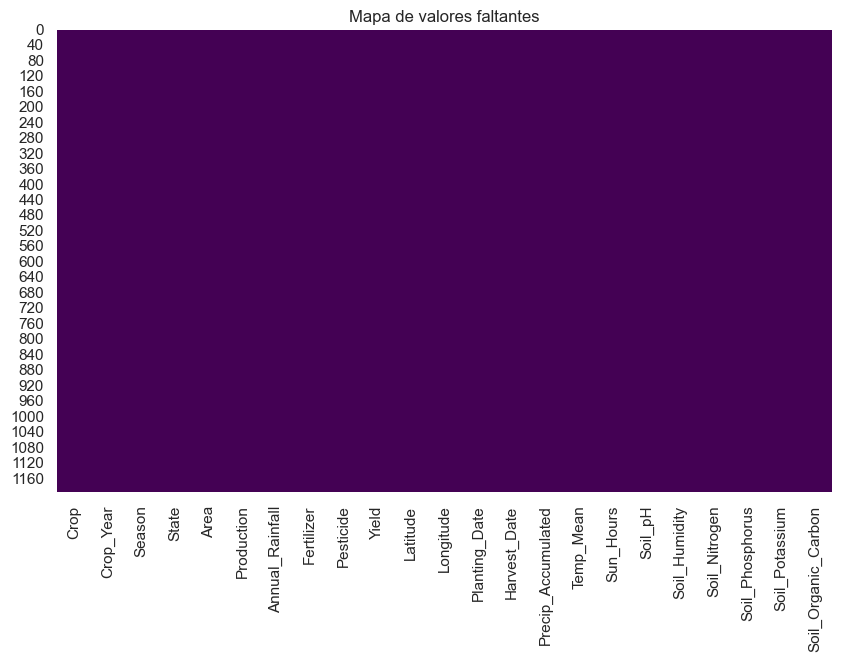

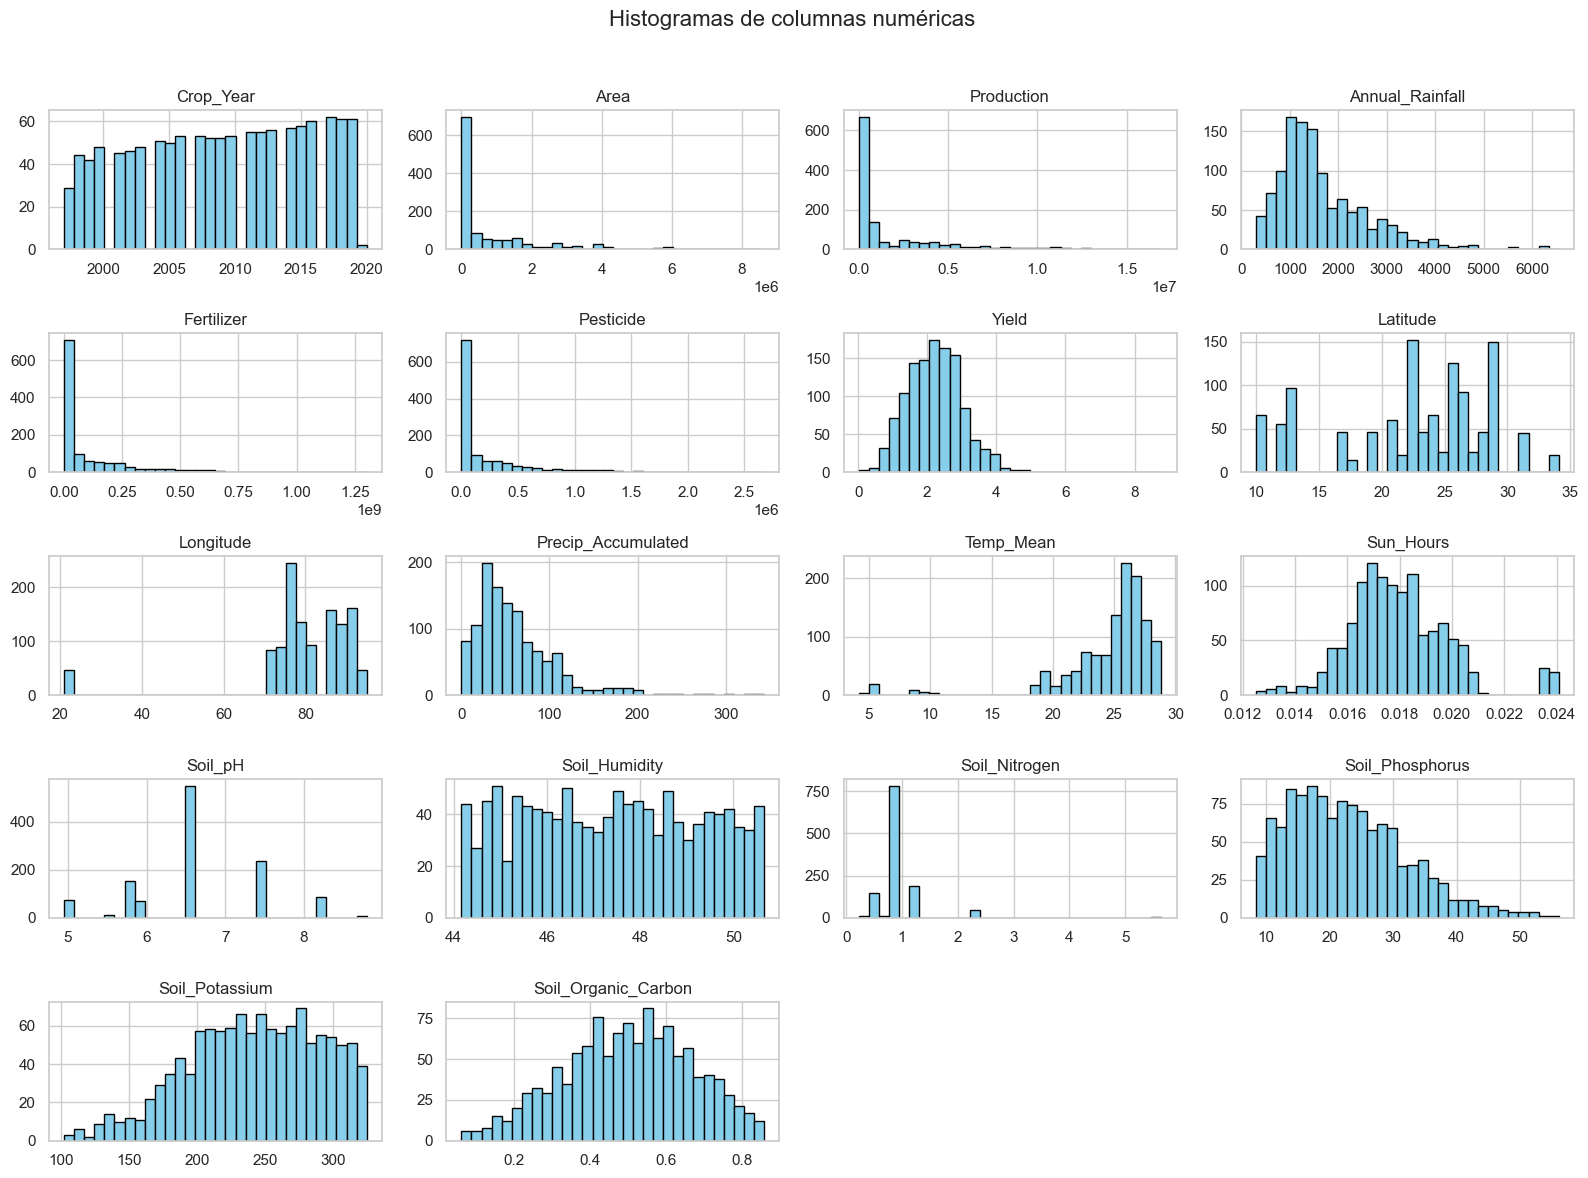

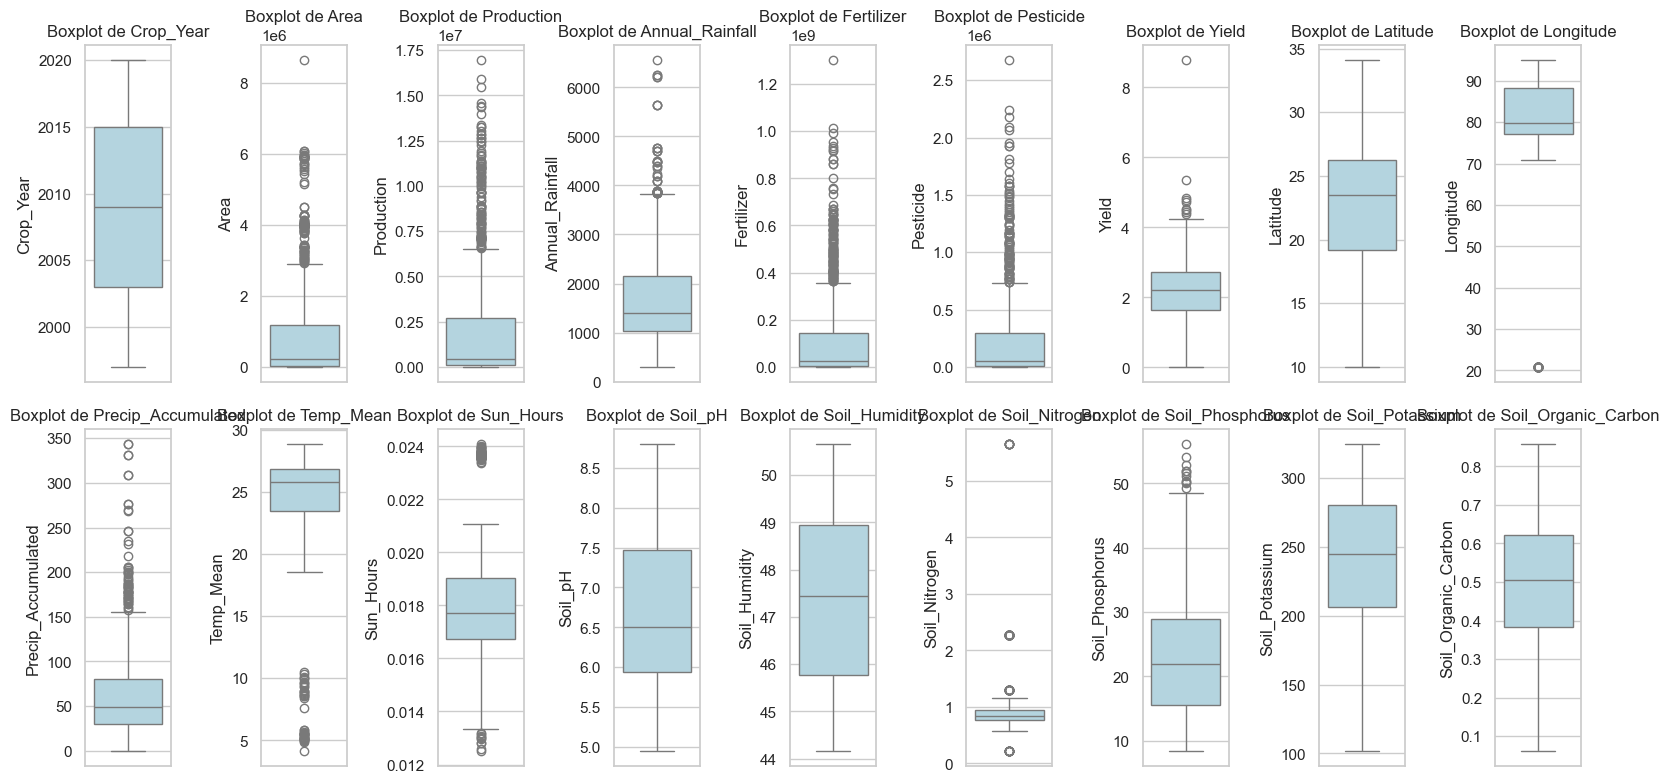

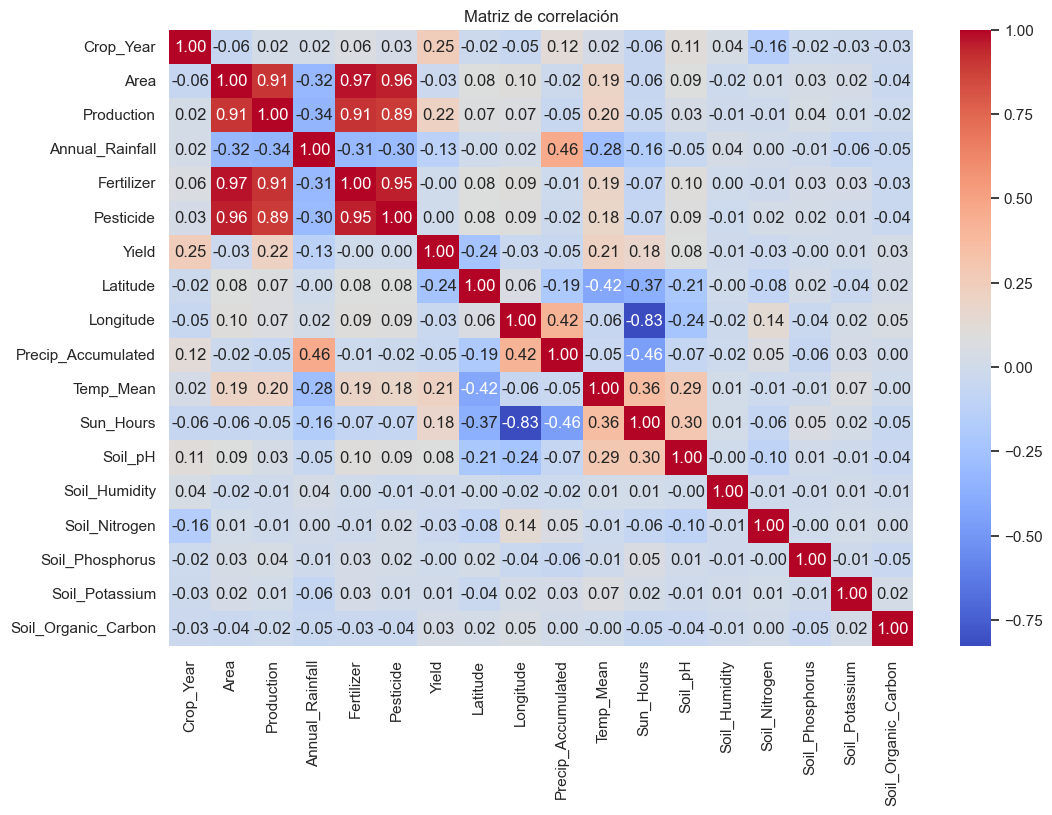


Principales correlaciones:
Fertilizer  Area          0.972954
Area        Fertilizer    0.972954
            Pesticide     0.955347
dtype: float64


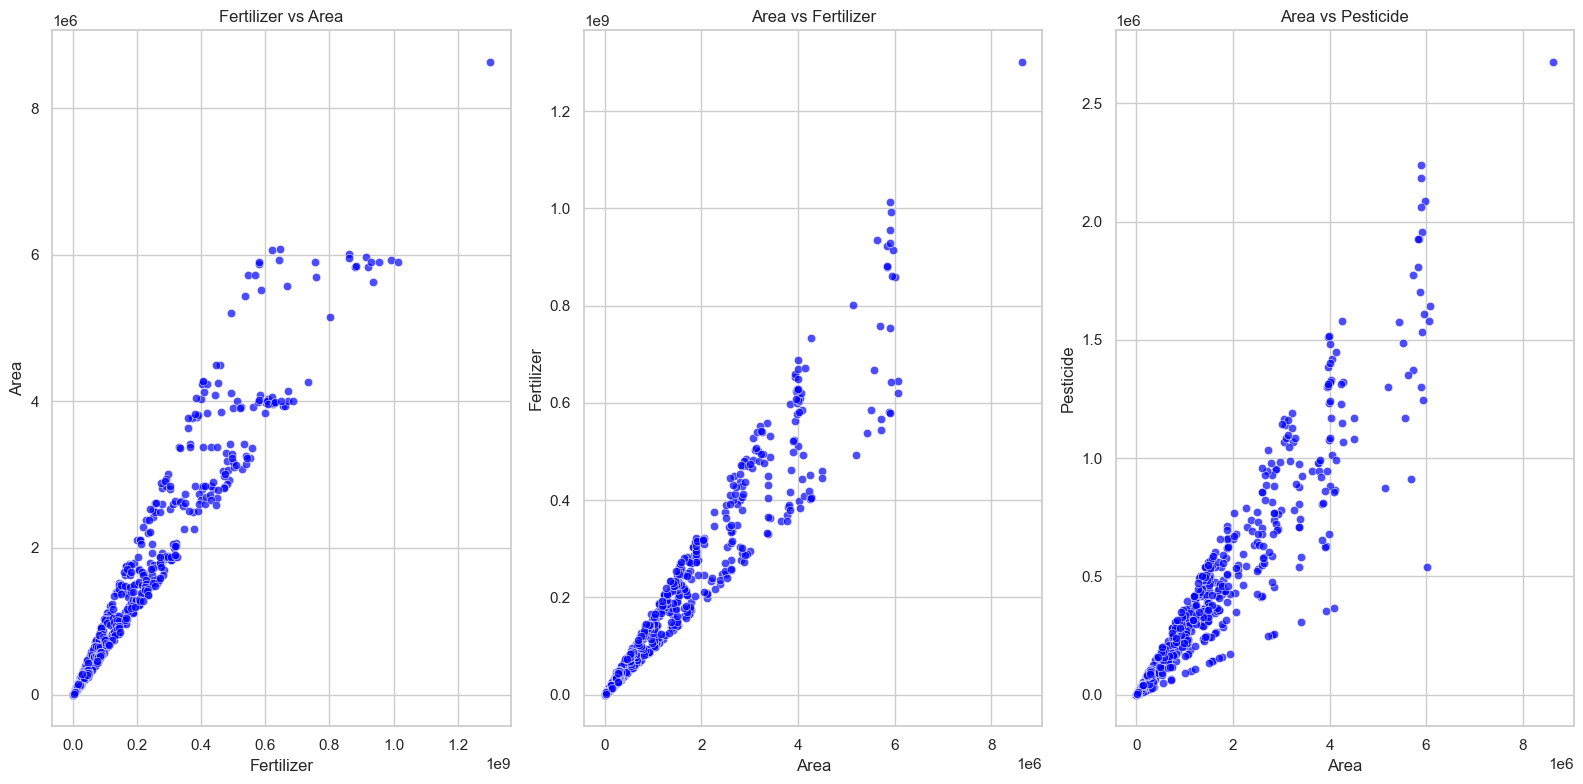

C:\Users\chuca\AppData\Local\Temp\ipykernel_22216\2309880566.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, palette='viridis', order=df[col].value_counts().index)


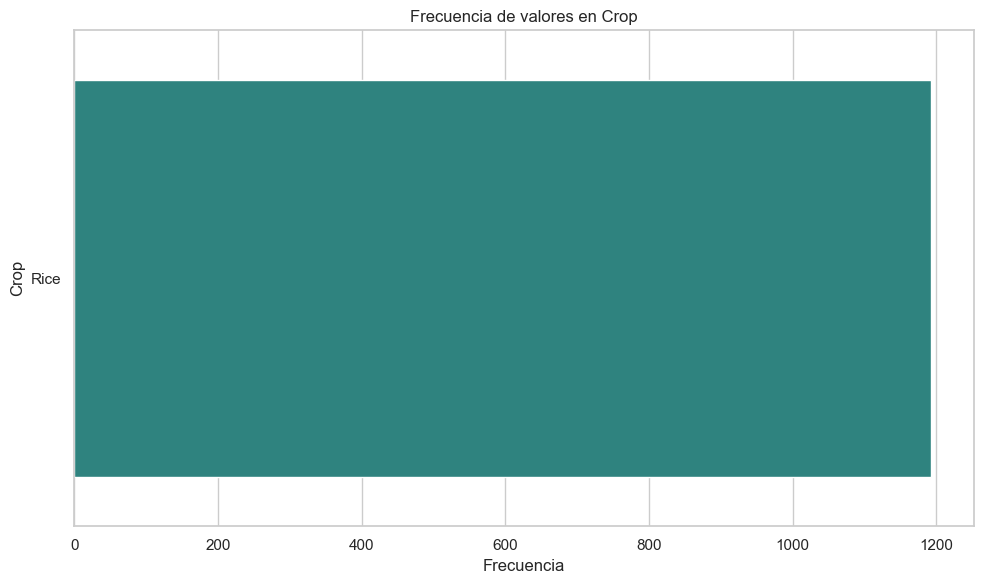

C:\Users\chuca\AppData\Local\Temp\ipykernel_22216\2309880566.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, palette='viridis', order=df[col].value_counts().index)


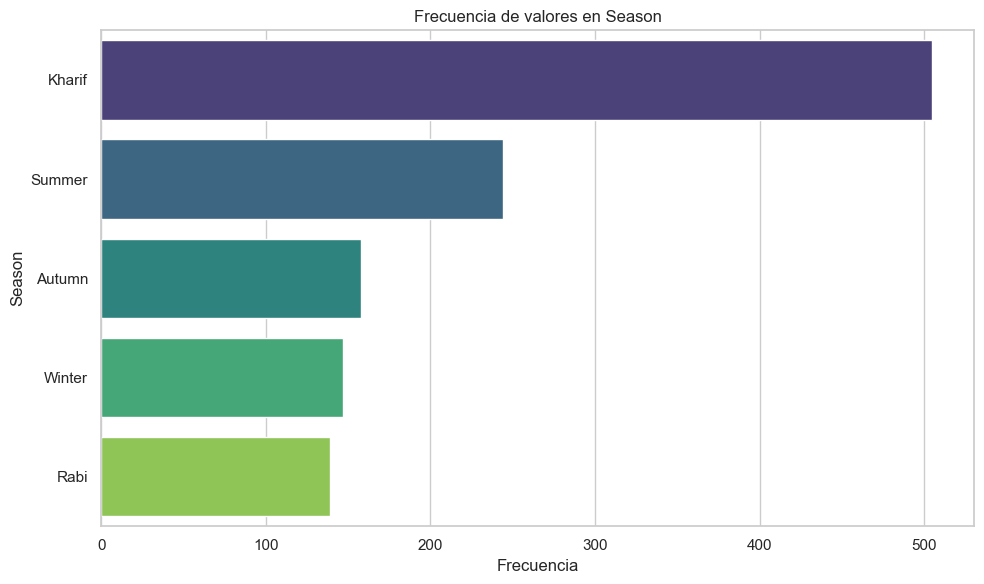

C:\Users\chuca\AppData\Local\Temp\ipykernel_22216\2309880566.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, palette='viridis', order=df[col].value_counts().index)


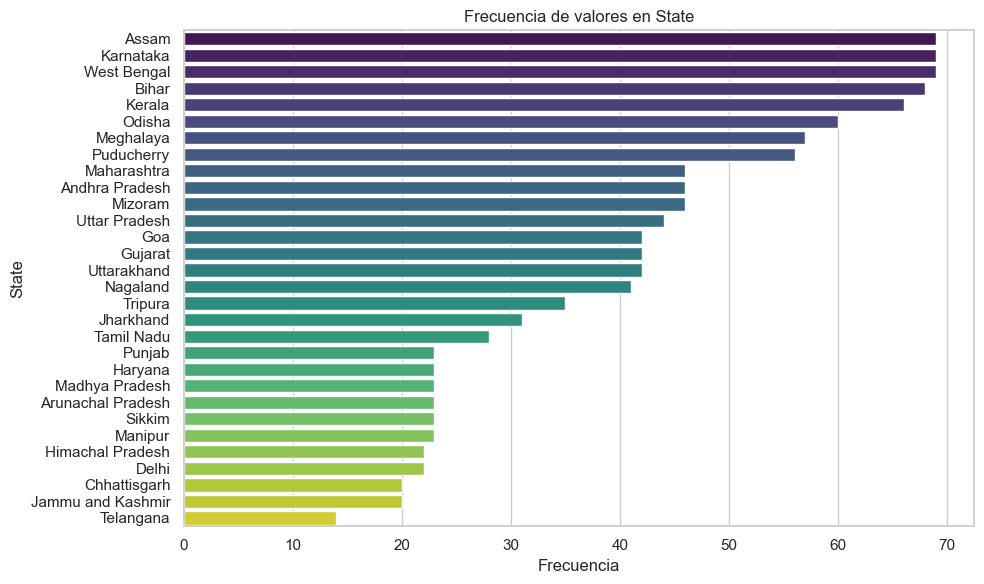

C:\Users\chuca\AppData\Local\Temp\ipykernel_22216\2309880566.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, palette='viridis', order=df[col].value_counts().index)


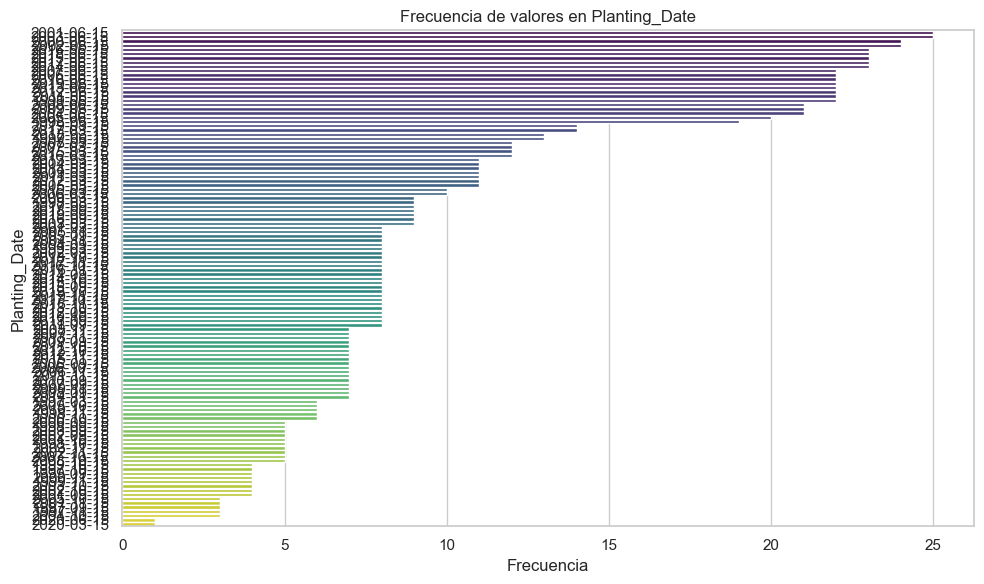

C:\Users\chuca\AppData\Local\Temp\ipykernel_22216\2309880566.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, palette='viridis', order=df[col].value_counts().index)


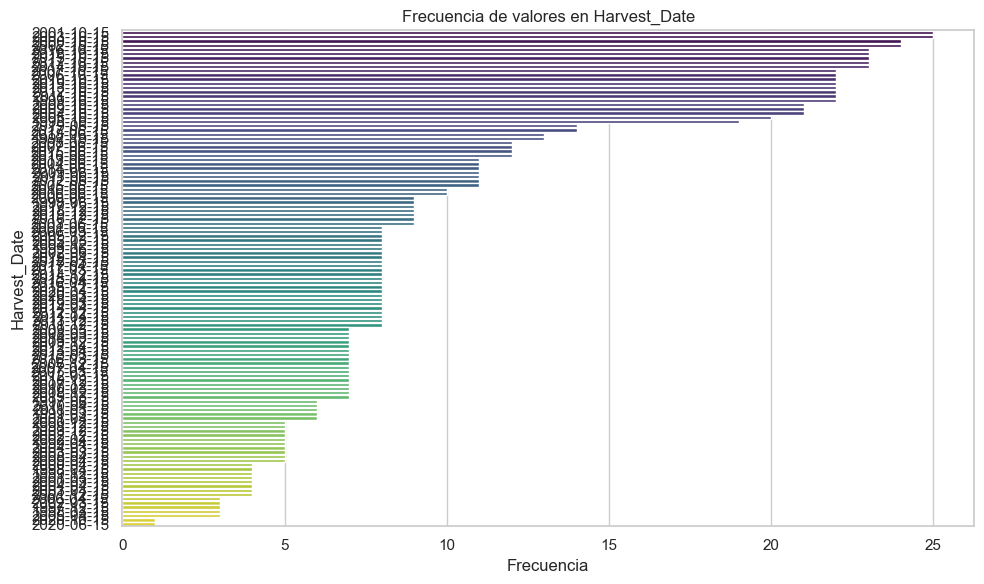

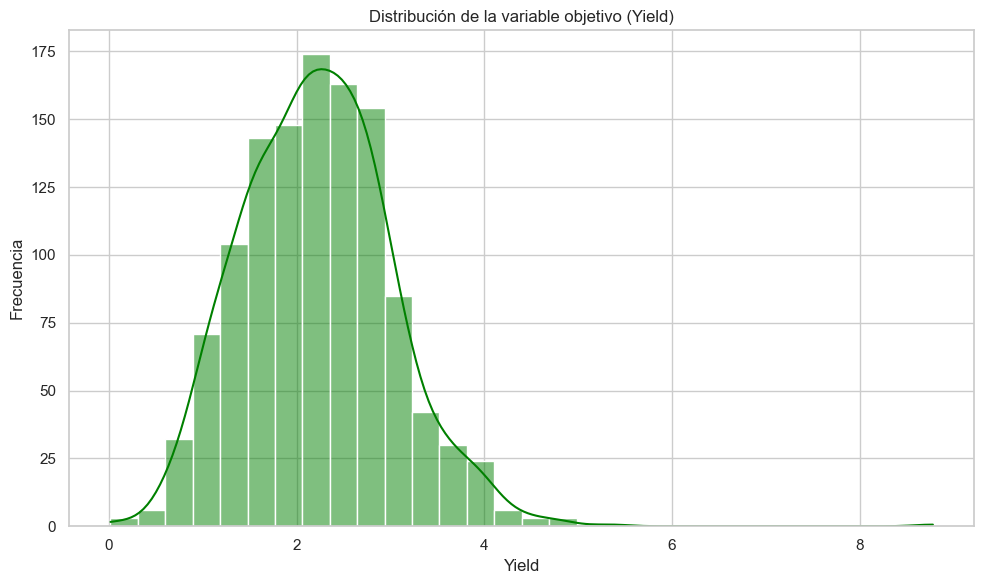

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para gráficos
sns.set_theme(style="whitegrid")

# Cargar el dataset (asegúrate de que el archivo esté en la misma carpeta o ajusta la ruta)
df = pd.read_csv('df_rice_filled_humidity.csv')

# 1. Información general del dataset
print("Información general del dataset:")
df.info()

# 2. Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())

# 3. Visualización de valores faltantes
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de valores faltantes')
plt.show()

# 4. Histogramas para todas las columnas numéricas
df.hist(figsize=(16, 12), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Histogramas de columnas numéricas', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 5. Boxplots para detectar outliers en columnas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(16, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, (len(num_cols) + 1) // 2, i)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

# 6. Matriz de correlación
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Matriz de correlación')
plt.show()

# 7. Gráficos de dispersión para las principales correlaciones
# Seleccionar las 3 correlaciones más altas (excluyendo la diagonal)
correlation_pairs = correlation_matrix.unstack().sort_values(ascending=False)
top_correlations = correlation_pairs[correlation_pairs < 1].head(3)
print("\nPrincipales correlaciones:")
print(top_correlations)

plt.figure(figsize=(16, 8))
for i, (col1, col2) in enumerate(top_correlations.index, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(x=numeric_df[col1], y=numeric_df[col2], alpha=0.7, color='blue')
    plt.title(f'{col1} vs {col2}')
    plt.xlabel(col1)
    plt.ylabel(col2)
plt.tight_layout()
plt.show()

# 8. Análisis de variables categóricas
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=col, data=df, palette='viridis', order=df[col].value_counts().index)
    plt.title(f'Frecuencia de valores en {col}')
    plt.xlabel('Frecuencia')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# 9. Distribución de la variable objetivo (si existe)
if 'Yield' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Yield'], kde=True, color='green', bins=30)
    plt.title('Distribución de la variable objetivo (Yield)')
    plt.xlabel('Yield')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

Entendiendo entonces que a partir de este análisis, ya no existen valores nulos, ni extraños dentro de este contexto, podemos continuar con la preparación del dataset.

# Preparación del Dataset para el entrenamiento

In [6]:
df_rice = pd.read_csv('df_rice_filled_humidity.csv')
df_rice.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,...,Harvest_Date,Precip_Accumulated,Temp_Mean,Sun_Hours,Soil_pH,Soil_Humidity,Soil_Nitrogen,Soil_Phosphorus,Soil_Potassium,Soil_Organic_Carbon
0,Rice,1997,Autumn,Assam,607358.0,398311,2051.4,5.780226e+07,188280.98,0.780870,...,1997-12-15,52.08,22.377692,0.016033,4.950000,47.805945,2.266667,23.720006,152.239530,0.564839
1,Rice,1997,Summer,Assam,174974.0,209623,2051.4,1.665228e+07,54241.94,1.060435,...,1997-06-15,52.08,22.377692,0.016033,4.950000,50.434803,2.266667,9.220294,210.491728,0.679662
2,Rice,1997,Winter,Assam,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.941304,...,1998-03-15,112.31,22.670000,0.016187,4.950000,44.899739,2.266667,25.458076,267.906191,0.615471
3,Rice,1997,Kharif,Karnataka,1031530.0,2340493,1266.7,9.817071e+07,319774.30,2.233500,...,1997-10-15,31.83,23.542308,0.019598,6.555556,45.704985,0.944607,31.904680,308.742235,0.366117
4,Rice,1997,Rabi,Karnataka,53889.0,109350,1266.7,5.128616e+06,16705.59,2.073846,...,1998-04-15,73.69,23.640000,0.019662,6.555556,44.693595,0.944607,24.223240,230.259043,0.658698


In [7]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd


# Convertir las columnas de fechas a tipo datetime
df_rice['Planting_Date'] = pd.to_datetime(df_rice['Planting_Date'], errors='coerce')
df_rice['Harvest_Date'] = pd.to_datetime(df_rice['Harvest_Date'], errors='coerce')

# Extraer el mes de las fechas de plantación y cosecha
df_rice['Planting_Month'] = df_rice['Planting_Date'].dt.month
df_rice['Harvest_Month'] = df_rice['Harvest_Date'].dt.month

# Convertir la columna Yield a Toneladas por Hectárea (asumiendo que está en Producción / Área)
df_rice['Yield'] = df_rice['Yield'] * 0.1  # Conversión a Toneladas por Hectárea

# Eliminar columnas innecesarias para el entrenamiento
columns_to_drop = ['Crop', 'Crop_Year', 'Latitude', 'Longitude', 'Planting_Date', 'Harvest_Date']
df_rice.drop(columns=columns_to_drop, inplace=True)

# Identificar columnas categóricas
categorical_cols = df_rice.select_dtypes(include=['object']).columns

# Aplicar One Hot Encoding a las columnas categóricas
encoder = OneHotEncoder(sparse_output=False, drop='first')  # Evitar colinealidad con drop='first'
encoded_features = encoder.fit_transform(df_rice[categorical_cols])
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

# Crear un DataFrame con las columnas codificadas
encoded_df = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df_rice.index)

# Concatenar las columnas codificadas al dataset original y eliminar las originales
df_rice = pd.concat([df_rice.drop(columns=categorical_cols), encoded_df], axis=1)

# Verificar el dataset final
print("Dataset listo para entrenamiento:")
print(df_rice.info())

# Guardar el dataset preparado
df_rice.to_csv('df_rice_prepared.csv', index=False)
print("Dataset preparado guardado en 'df_rice_prepared.csv'")

Dataset listo para entrenamiento:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1193 entries, 0 to 1192
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Area                     1193 non-null   float64
 1   Production               1193 non-null   int64  
 2   Annual_Rainfall          1193 non-null   float64
 3   Fertilizer               1193 non-null   float64
 4   Pesticide                1193 non-null   float64
 5   Yield                    1193 non-null   float64
 6   Precip_Accumulated       1193 non-null   float64
 7   Temp_Mean                1193 non-null   float64
 8   Sun_Hours                1193 non-null   float64
 9   Soil_pH                  1193 non-null   float64
 10  Soil_Humidity            1193 non-null   float64
 11  Soil_Nitrogen            1193 non-null   float64
 12  Soil_Phosphorus          1193 non-null   float64
 13  Soil_Potassium           1193 non-null   flo

# Entrenamiento de los modelos

In [9]:
import pandas as pd
import joblib

In [10]:
df_rice_prepared = pd.read_csv('df_rice_prepared.csv')
df_rice_prepared.head()

,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Precip_Accumulated,Temp_Mean,Sun_Hours,Soil_pH,...,State_Odisha,State_Puducherry,State_Punjab,State_Sikkim,State_Tamil Nadu,State_Telangana,State_Tripura,State_Uttar Pradesh,State_Uttarakhand,State_West Bengal
0,607358.0,398311,2051.4,5.780226e+07,188280.98,0.078087,52.08,22.377692,0.016033,4.950000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,174974.0,209623,2051.4,1.665228e+07,54241.94,0.106043,52.08,22.377692,0.016033,4.950000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.094130,112.31,22.670000,0.016187,4.950000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1031530.0,2340493,1266.7,9.817071e+07,319774.30,0.223350,31.83,23.542308,0.019598,6.555556,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,53889.0,109350,1266.7,5.128616e+06,16705.59,0.207385,73.69,23.640000,0.019662,6.555556,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Selección de características y variable objetivo
X = df_rice_prepared.drop(columns=['Yield'])
y = df_rice_prepared['Yield']

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Modelos clásicos
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(n_jobs=-1),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor()
}

# Modelos avanzados
advanced_models = {
    'XGBoost': XGBRegressor(n_jobs=-1),
    'LightGBM': LGBMRegressor(n_jobs=-1),
    'CatBoost': CatBoostRegressor(verbose=0, train_dir=None)
}

from sklearn.model_selection import cross_val_score

# Diccionario para almacenar resultados
results = {}

# Entrenamiento de modelos clásicos y avanzados
print("Training models...")
for name, model in tqdm({**models, **advanced_models}.items(), desc="Modelos"):
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    results[name] = np.sqrt(-scores.mean())

# Mostrar resultados preliminares
print("\nPreliminary results:")
for model_name, rmse in results.items():
    print(f"{model_name}: RMSE = {rmse:.4f}")



Training models...


Modelos:   0%|          | 0/10 [00:00<?, ?it/s]

Modelos: 100%|██████████| 10/10 [00:56<00:00,  5.63s/it]


Preliminary results:
Linear Regression: RMSE = 0.0391
Ridge: RMSE = 0.0391
Lasso: RMSE = 0.0779
Decision Tree: RMSE = 0.0480
Random Forest: RMSE = 0.0361
SVR: RMSE = 0.0591
KNN: RMSE = 0.0399
XGBoost: RMSE = 0.0328
LightGBM: RMSE = 0.0341
CatBoost: RMSE = 0.0320


* Cantidad de Capas Ocultas:
    * Motivo: El número de capas ocultas depende de la complejidad del problema. Para problemas no lineales como la predicción de rendimiento de cultivos, una red con 2-3 capas ocultas suele ser suficiente para capturar patrones complejos sin sobreajustar, sobre todo con pocos datos como lo es en este caso.
    * Implementación: Usaremos 2 capas ocultas para equilibrar la capacidad de modelado y la simplicidad.
*Número de Neuronas por Capa:
    * Motivo: El número de neuronas en cada capa debe ser suficiente para capturar las relaciones entre las características. Comenzaremos con un número de neuronas similar al número de características de entrada y lo reduciremos en las capas posteriores.
    * Implementación: Si el dataset tiene n_features, usaremos:
        * Primera capa: n_features * 2 neuronas.
        * Segunda capa: n_features neuronas.
* Funciones de Activación:
    * Motivo: La función de activación introduce no linealidad en la red. Para problemas de regresión, ReLU es una opción común porque evita problemas de gradientes desaparecidos y es eficiente computacionalmente.
    * Implementación: Usaremos ReLU en las capas ocultas y una función lineal (implícita) en la capa de salida para regresión.
* Optimizador y Tasa de Aprendizaje:
    * Motivo: El optimizador adam es robusto y funciona bien en la mayoría de los casos. La tasa de aprendizaje puede ajustarse mediante validación cruzada.
    * Implementación: Usaremos adam con su tasa de aprendizaje predeterminada.
* Regularización:
    * Motivo: Para evitar el sobreajuste, podemos usar regularización L2 (alpha) y/o dropout.
    * Implementación: Ajustaremos alpha mediante validación cruzada.

In [12]:
from tqdm import tqdm
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV

# Determinar el número de características de entrada
n_features = X_train_scaled.shape[1]

# Definir la arquitectura del MLP
mlp = MLPRegressor(
    hidden_layer_sizes=(n_features * 3, n_features * 2, n_features),  # Tres capas ocultas
    activation='relu',  # Función de activación ReLU
    solver='adam',  # Optimizador Adam
    max_iter=1000,  # Aumentar iteraciones para asegurar convergencia
    random_state=42
)

# Hiperparámetros para ajustar
param_grid = {
    'alpha': [0.0001, 0.001, 0.01],  # Regularización L2
    'learning_rate_init': [0.001, 0.01, 0.1]  # Tasa de aprendizaje inicial
}

# Búsqueda de hiperparámetros con validación cruzada
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Mejor modelo
best_mlp = grid_search.best_estimator_

# Calcular RMSE para el mejor MLP usando cross_val_score
mlp_scores = cross_val_score(best_mlp, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
results['MLP'] = np.sqrt(-mlp_scores.mean())

# Mostrar resultados
print(f"Best MLP configuration: {grid_search.best_params_}")
print(f"MLP Result: RMSE = {results['MLP']:.4f}")

Best MLP configuration: {'alpha': 0.01, 'learning_rate_init': 0.01}
MLP Result: RMSE = 0.0434



Comparativa de Resultados:
                       RMSE
CatBoost           0.032020
XGBoost            0.032755
LightGBM           0.034095
Random Forest      0.036088
Ridge              0.039067
Linear Regression  0.039146
KNN                0.039852
MLP                0.043406
Decision Tree      0.047950
SVR                0.059113
Lasso              0.077943


C:\Users\chuca\AppData\Local\Temp\ipykernel_3832\3359982551.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['RMSE'], palette='viridis')


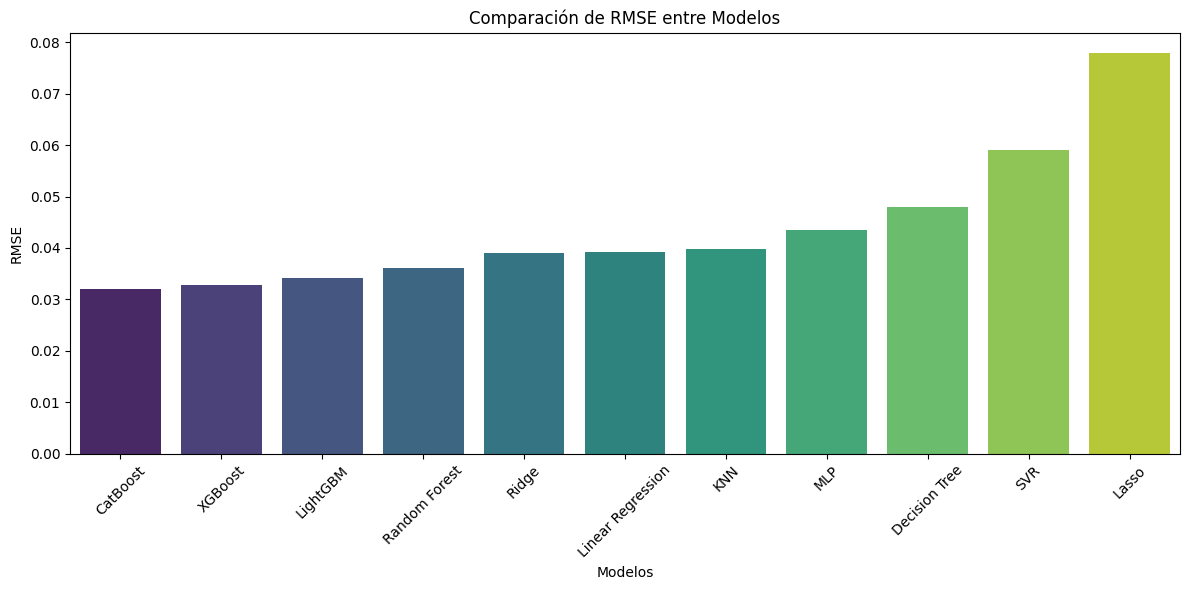

Calculando métricas para el modelo: Linear Regression


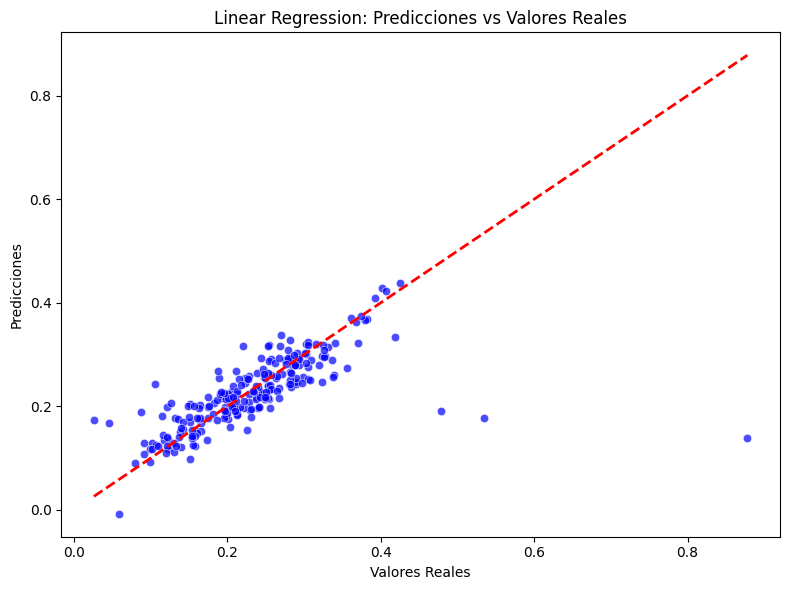

Calculando métricas para el modelo: Ridge


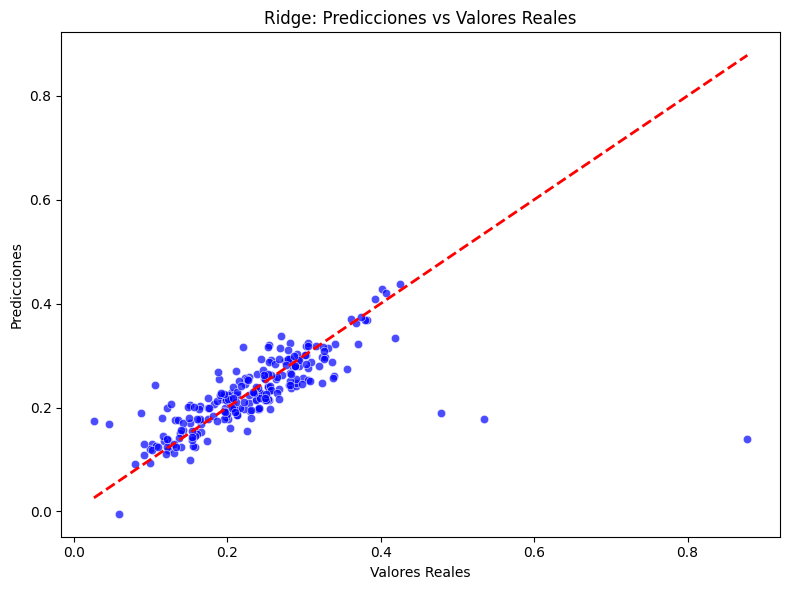

Calculando métricas para el modelo: Lasso


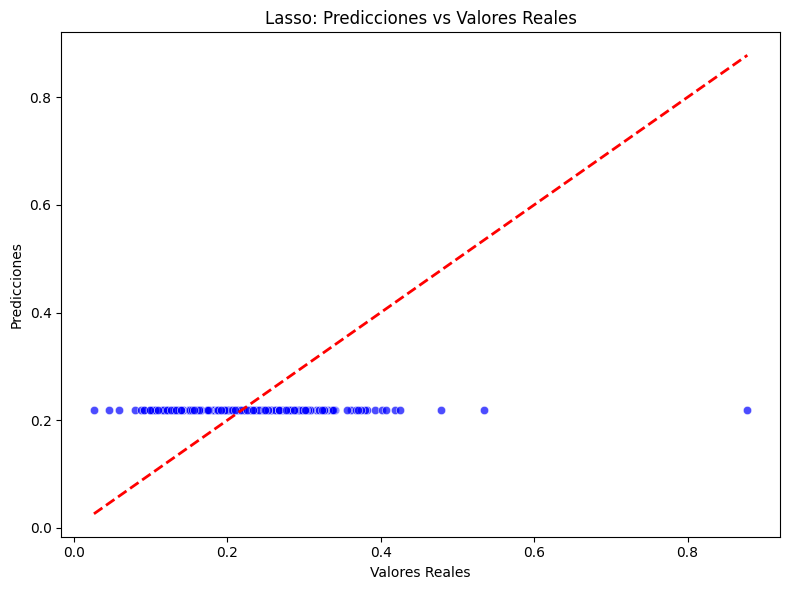

Calculando métricas para el modelo: Decision Tree


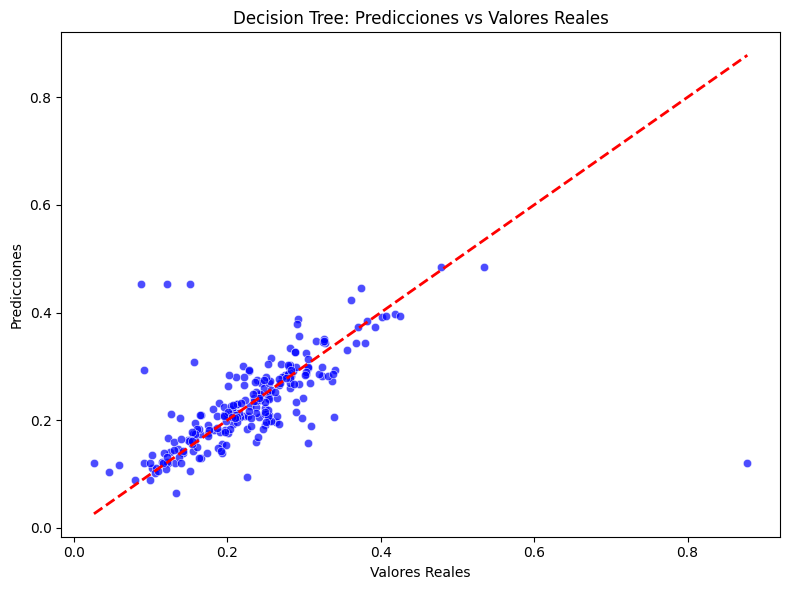

Calculando métricas para el modelo: Random Forest


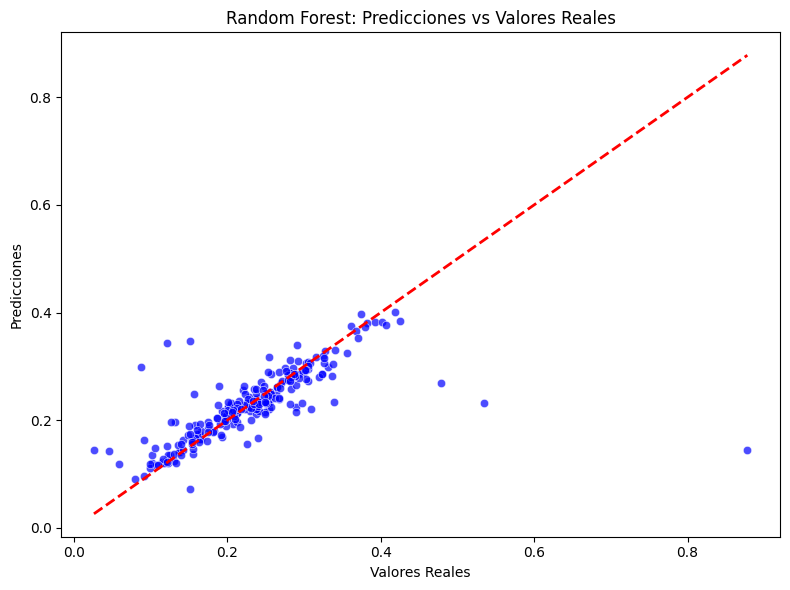

Calculando métricas para el modelo: SVR


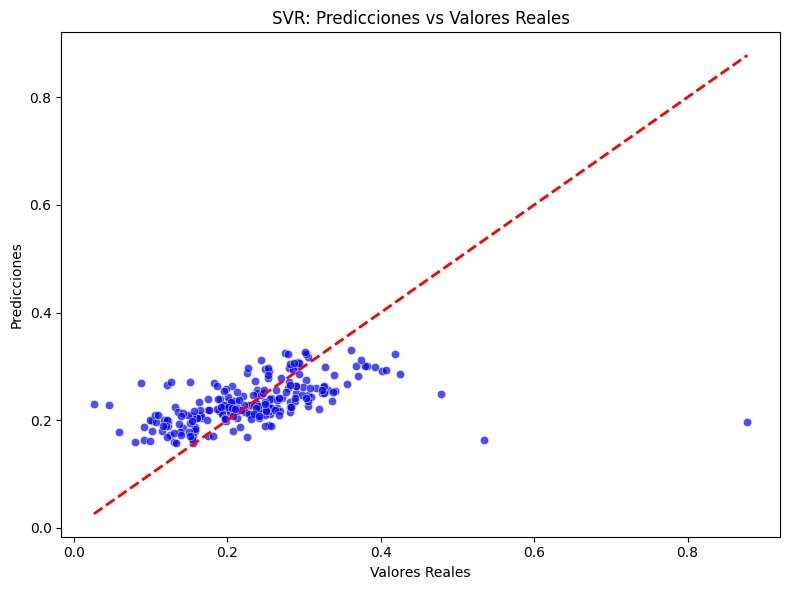

Calculando métricas para el modelo: KNN


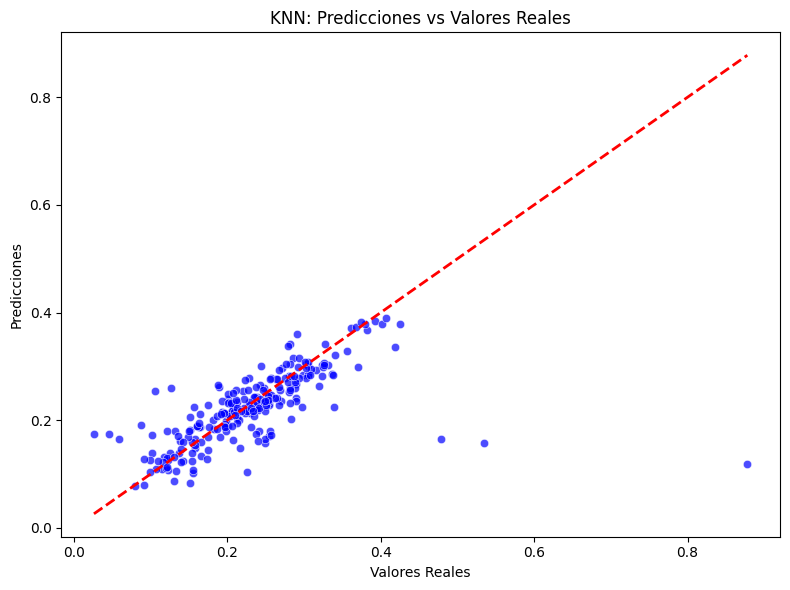

Calculando métricas para el modelo: XGBoost


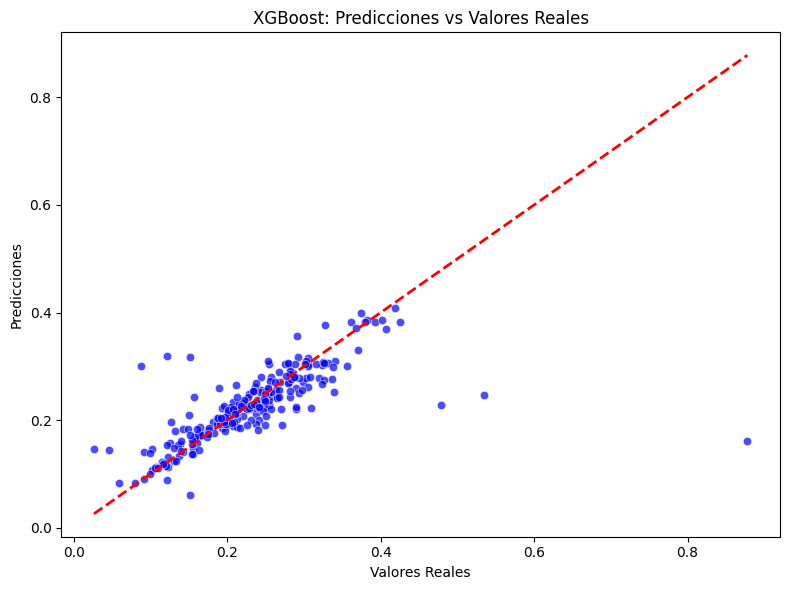

Calculando métricas para el modelo: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000971 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3165
[LightGBM] [Info] Number of data points in the train set: 954, number of used features: 40
[LightGBM] [Info] Start training from score 0.219902


C:\Users\chuca\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


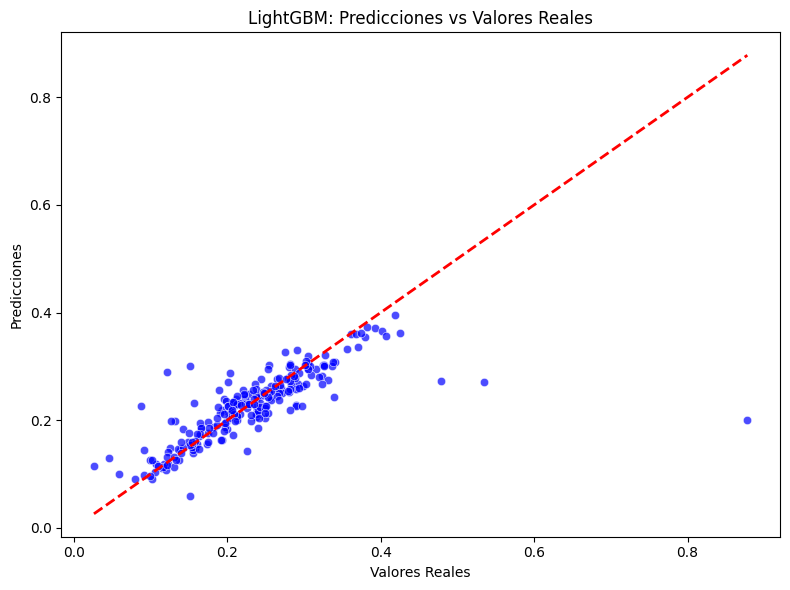

Calculando métricas para el modelo: CatBoost


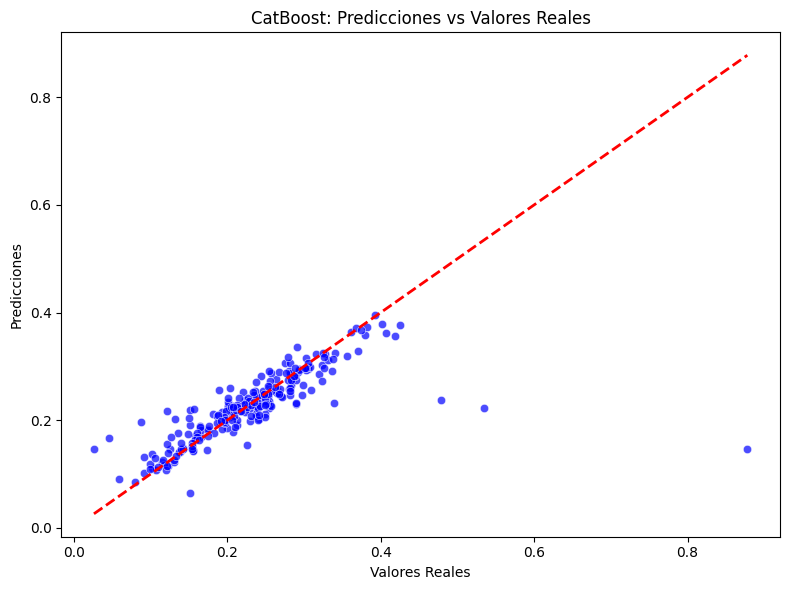

Calculando métricas para el modelo: MLP


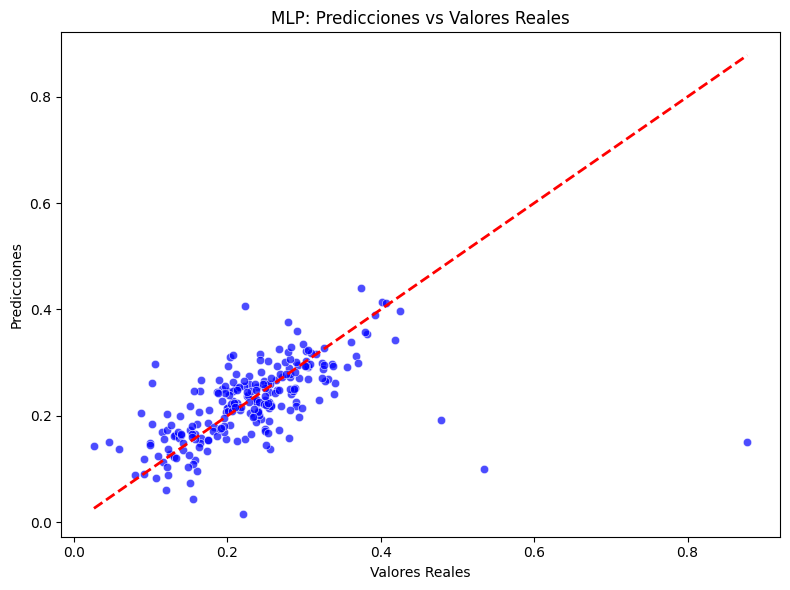


Métricas Detalladas:
                       RMSE       MAE        R²
Linear Regression  0.066431  0.032108  0.432925
Ridge              0.066424  0.032109  0.433039
Lasso              0.088884  0.063478 -0.015206
Decision Tree      0.074062  0.035727  0.295149
Random Forest      0.064290  0.026588  0.468880
SVR                0.076205  0.048924  0.253781
KNN                0.070405  0.034035  0.363044
XGBoost            0.063812  0.027916  0.476751
LightGBM           0.059025  0.026965  0.552317
CatBoost           0.061034  0.025241  0.521323
MLP                0.077490  0.044178  0.228394


C:\Users\chuca\AppData\Local\Temp\ipykernel_3832\3359982551.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=detailed_results_df.index, y=detailed_results_df['RMSE'], ax=axes[0], palette='viridis')
C:\Users\chuca\AppData\Local\Temp\ipykernel_3832\3359982551.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=detailed_results_df.index, y=detailed_results_df['MAE'], ax=axes[1], palette='viridis')
C:\Users\chuca\AppData\Local\Temp\ipykernel_3832\3359982551.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=detailed_results_df.index

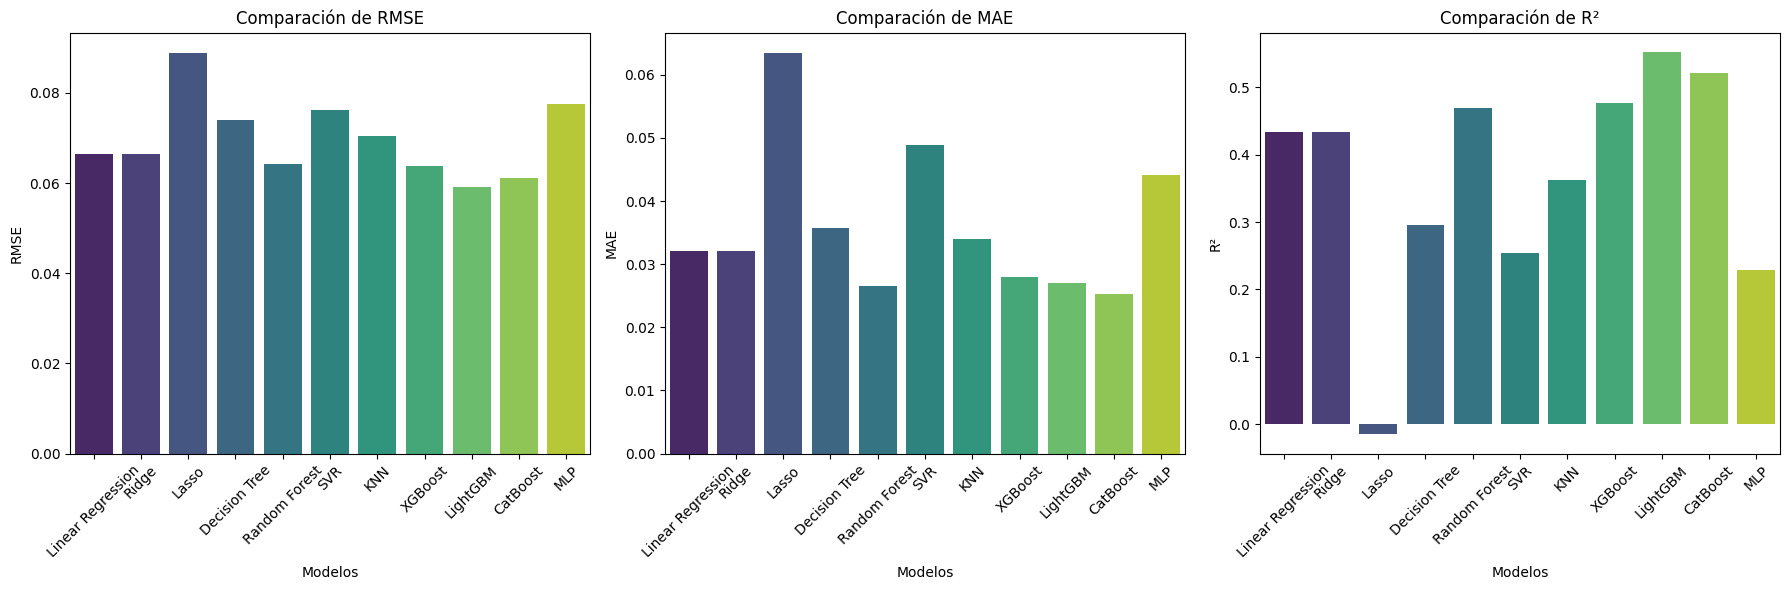

In [13]:
# Comparativa extensa de resultados
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Crear un DataFrame con los resultados
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['RMSE'])
results_df.sort_values(by='RMSE', inplace=True)

# Mostrar tabla de resultados
print("\nComparativa de Resultados:")
print(results_df)

# Gráfico de barras de RMSE
plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y=results_df['RMSE'], palette='viridis')
plt.title('Comparación de RMSE entre Modelos')
plt.ylabel('RMSE')
plt.xlabel('Modelos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Predicciones y métricas adicionales para cada modelo
detailed_results = {}
for name, model in {**models, **advanced_models, 'MLP': mlp}.items():
    print(f"Calculando métricas para el modelo: {name}")
    model.fit(X_train_scaled, y_train)  # Entrenar el modelo
    y_pred = model.predict(X_test_scaled)  # Predicciones en el conjunto de prueba
    
    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Guardar métricas
    detailed_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    
    # Gráfico de dispersión: Predicciones vs Valores Reales
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
    plt.title(f'{name}: Predicciones vs Valores Reales')
    plt.xlabel('Valores Reales')
    plt.ylabel('Predicciones')
    plt.tight_layout()
    plt.show()

# Crear un DataFrame con las métricas detalladas
detailed_results_df = pd.DataFrame(detailed_results).T
print("\nMétricas Detalladas:")
print(detailed_results_df)

# Gráfico comparativo de métricas (RMSE, MAE, R²)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RMSE
sns.barplot(x=detailed_results_df.index, y=detailed_results_df['RMSE'], ax=axes[0], palette='viridis')
axes[0].set_title('Comparación de RMSE')
axes[0].set_ylabel('RMSE')
axes[0].set_xlabel('Modelos')
axes[0].tick_params(axis='x', rotation=45)

# MAE
sns.barplot(x=detailed_results_df.index, y=detailed_results_df['MAE'], ax=axes[1], palette='viridis')
axes[1].set_title('Comparación de MAE')
axes[1].set_ylabel('MAE')
axes[1].set_xlabel('Modelos')
axes[1].tick_params(axis='x', rotation=45)

# R²
sns.barplot(x=detailed_results_df.index, y=detailed_results_df['R²'], ax=axes[2], palette='viridis')
axes[2].set_title('Comparación de R²')
axes[2].set_ylabel('R²')
axes[2].set_xlabel('Modelos')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [14]:
mlp_model = best_mlp

# Entrenar el mejor modelo en todo el conjunto de entrenamiento
mlp_model.fit(X_train_scaled, y_train)

# Guardar el modelo y el escalador
joblib.dump(mlp_model, 'mlp_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
mlp_model = joblib.load('mlp_model.pkl')
scaler = joblib.load('scaler.pkl')


new_data = pd.DataFrame({
    'Area': [100],  # área en hectáreas
    'Precip_Accumulated': [500],  # Precipitación acumulada
    'Temp_Mean': [25],  # Temperatura media
    'Sun_Hours': [2000],  # Horas de sol
    'Soil_pH': [6.5],  # pH del suelo
    'Soil_Humidity': [45],  # Humedad del suelo
    'Soil_Nitrogen': [0.5],  # Nitrógeno
    'Soil_Phosphorus': [20],  # Fósforo
    'Soil_Potassium': [250],  # Potasio
    'Soil_Organic_Carbon': [0.5],  # Carbono orgánico
    'Planting_Month': [6],  # Mes de plantación
    'Harvest_Month': [10],  # Mes de cosecha
    #...
    'State_Andhra Pradesh': [1],
    'State_Bihar': [0],
    # ... 
    'Season_Kharif': [1], 
    'Season_Rabi': [0], 
    # ... 
})

# Si faltan columnas, se agregan con valor 0
missing_cols = set(X_train.columns) - set(new_data.columns)
for col in missing_cols:
    new_data[col] = 0
new_data = new_data[X_train.columns]

# Escalar los datos nuevos
new_data_scaled = scaler.transform(new_data)

# Hacer predicción
prediction = mlp_model.predict(new_data_scaled)
print(f"Predicción de rendimiento (Yield) para los datos nuevos: {prediction[0]:.2f} toneladas por hectárea")

Predicción de rendimiento (Yield) para los datos nuevos: 19780.50 toneladas por hectárea


La predicción puede carecer de sentido, pero en gran parte por que los datos usados de prueba (new_data) no tienen consistencia ni están completos.